# 01 — Exploratory Data Analysis
Silver prices, macro covariates, and return series.


In [168]:
import sys, os
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from eda_utils import eda_transform

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load data

In [169]:
prices = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
macro  = pd.read_csv('../data/raw/monthly_macro.csv', index_col=0, parse_dates=True)

silver = prices['silver'].dropna()
print(prices.shape, macro.shape)
prices.head()

(2854, 8) (2991, 6)


,silver,gold,usd_index,sp500,tip_etf,copper,vix,oil
Date,,,,,,,,
2015-01-02,15.734000,1186.000000,91.080002,2058.199951,84.513382,2.8385,17.790001,52.689999
2015-01-05,16.179001,1203.900024,91.379997,2020.579956,84.580849,2.7930,19.920000,50.040001
2015-01-06,16.603001,1219.300049,91.500000,2002.609985,84.588341,2.8040,21.120001,47.930000
2015-01-07,16.510000,1210.599976,91.889999,2025.900024,84.655792,2.7960,19.309999,48.650002
2015-01-08,16.351000,1208.400024,92.370003,2062.139893,84.520889,2.8070,17.010000,48.790001


## 2. Silver price level

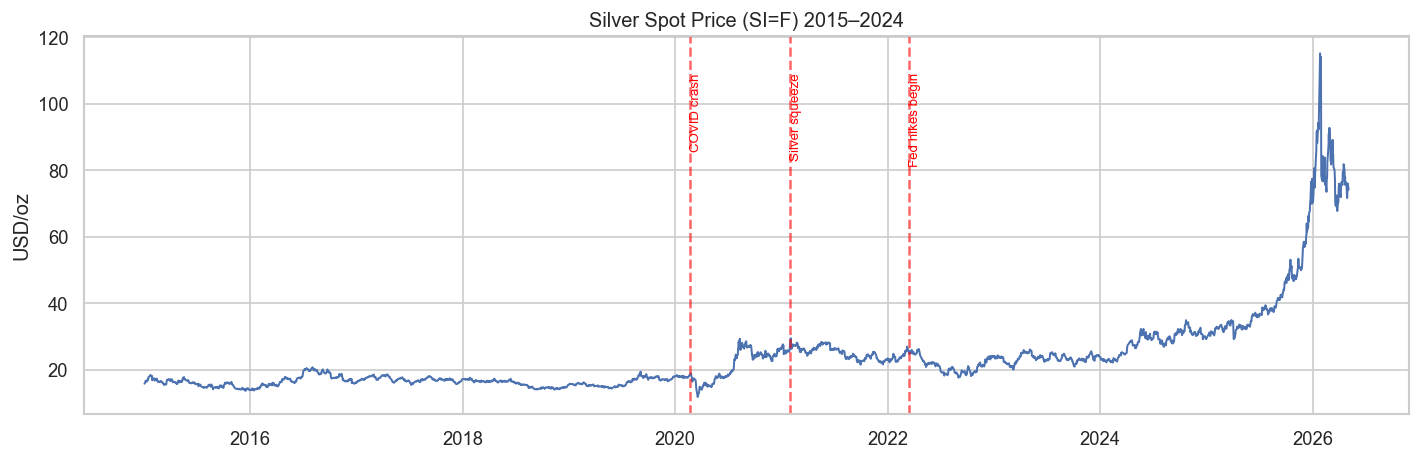

In [170]:
# Annotate key events
events = {
    'COVID crash': '2020-02-20',
    'Silver squeeze': '2021-01-28',
    'Fed hikes begin': '2022-03-16',
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(silver, lw=1.2, label='Silver (SI=F)')
for label, date in events.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.6)
    ax.text(pd.to_datetime(date), silver.max() * 0.95, label,
            rotation=90, fontsize=8, color='red', va='top')
ax.set_title('Silver Spot Price (SI=F) 2015–2024')
ax.set_ylabel('USD/oz')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. EDA on price level (expect non-stationary)

No transform applied.


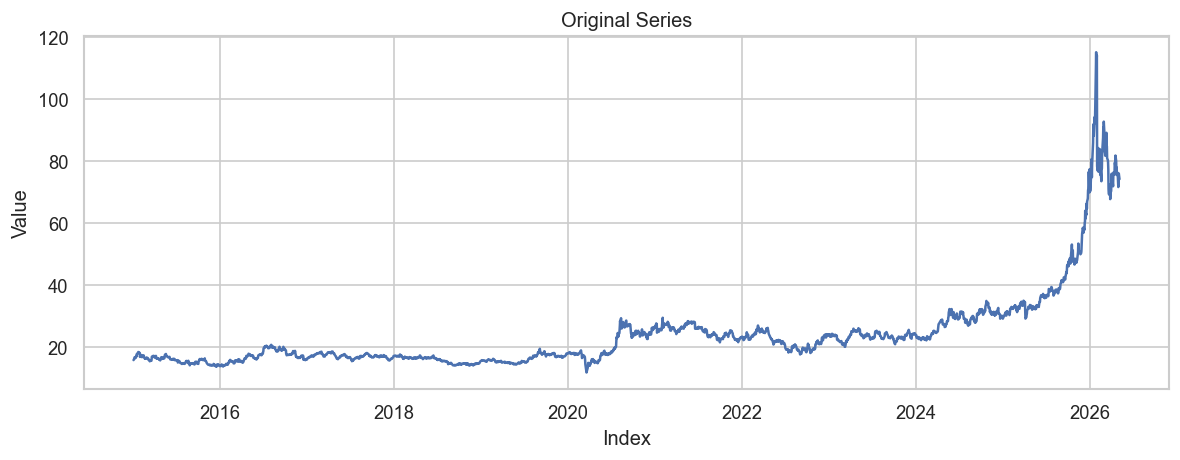

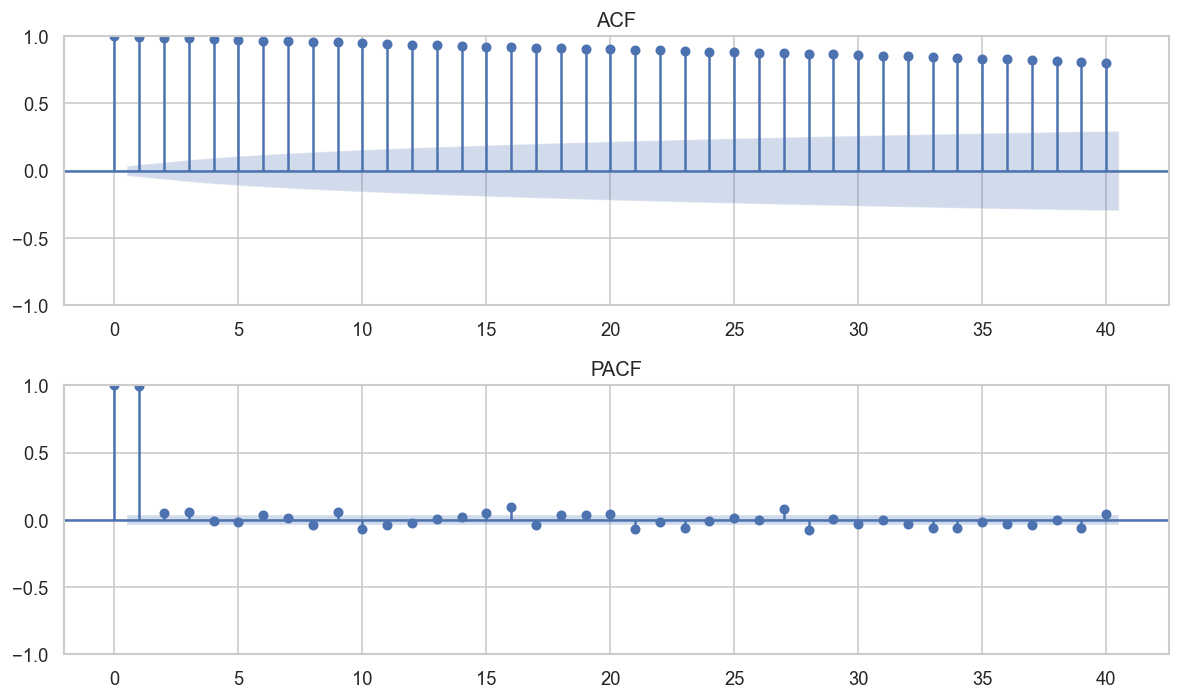

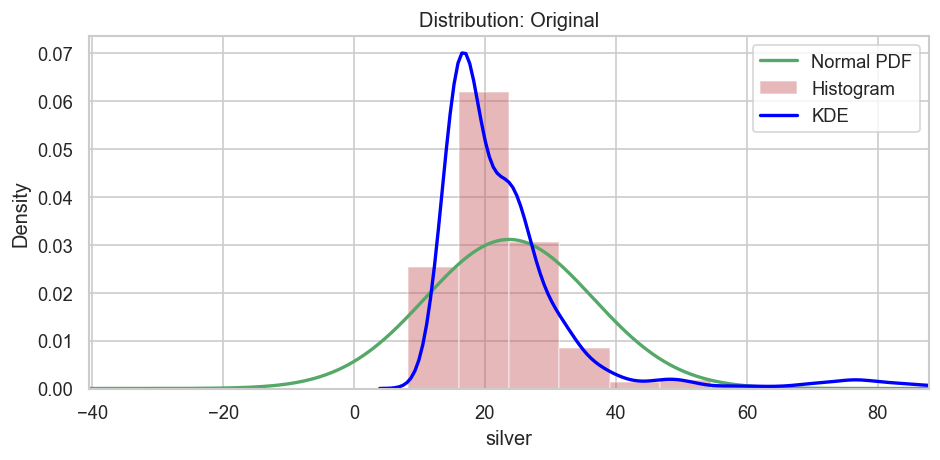

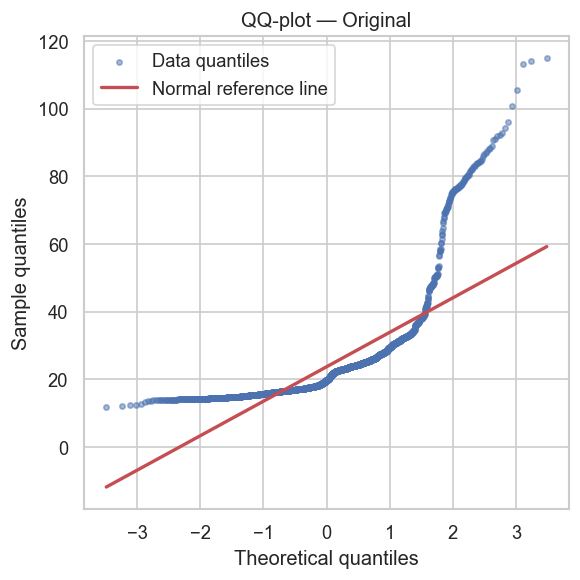

  QQ R²: 0.6308 (1.0 = perfect normal)

ADF Test:
  Statistic: 1.0816
  p-value:   0.9951
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Non-stationary (fail to reject H₀)

Ljung-Box:
  lag=5: p-value = 0.0000  → Autocorrelation present
  lag=10: p-value = 0.0000  → Autocorrelation present
  lag=20: p-value = 0.0000  → Autocorrelation present
  lag=60: p-value = 0.0000  → Autocorrelation present

Shapiro-Wilk:         stat=0.6313, p=0.0000  → NOT normal
D'Agostino K²:        stat=1980.3694, p=0.0000  → NOT normal
Anderson-Darling:     stat=279.7351
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.2172, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2724.57, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared residuals:
  lag=5: p-value = 0.0000  → ARCH effects likely
  lag=10: p-value 

/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:119: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [171]:
result_level = eda_transform(silver, transform=None, lags=40)

## 4. Return transforms

#### Simple returns (`pct_change`) — shown for comparison

No transform applied.


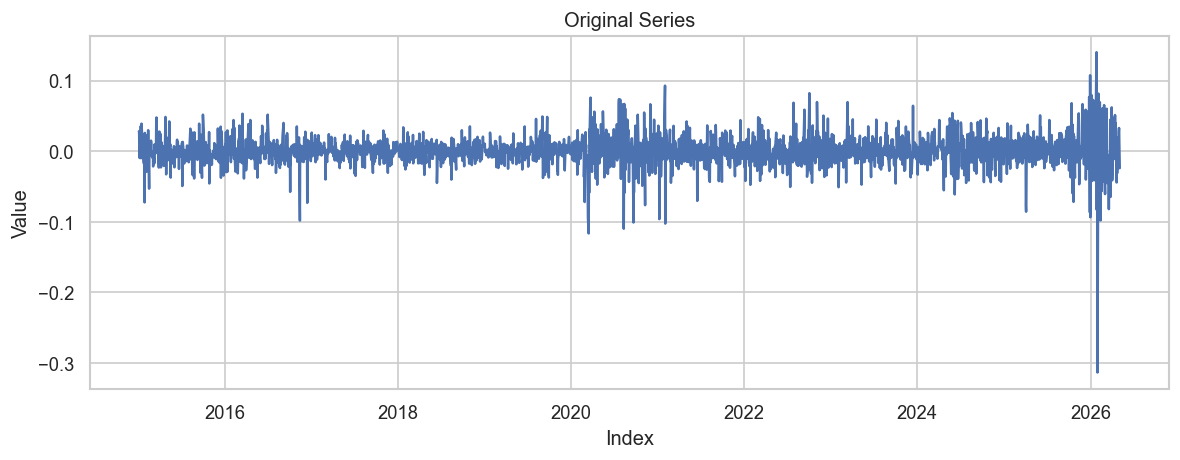

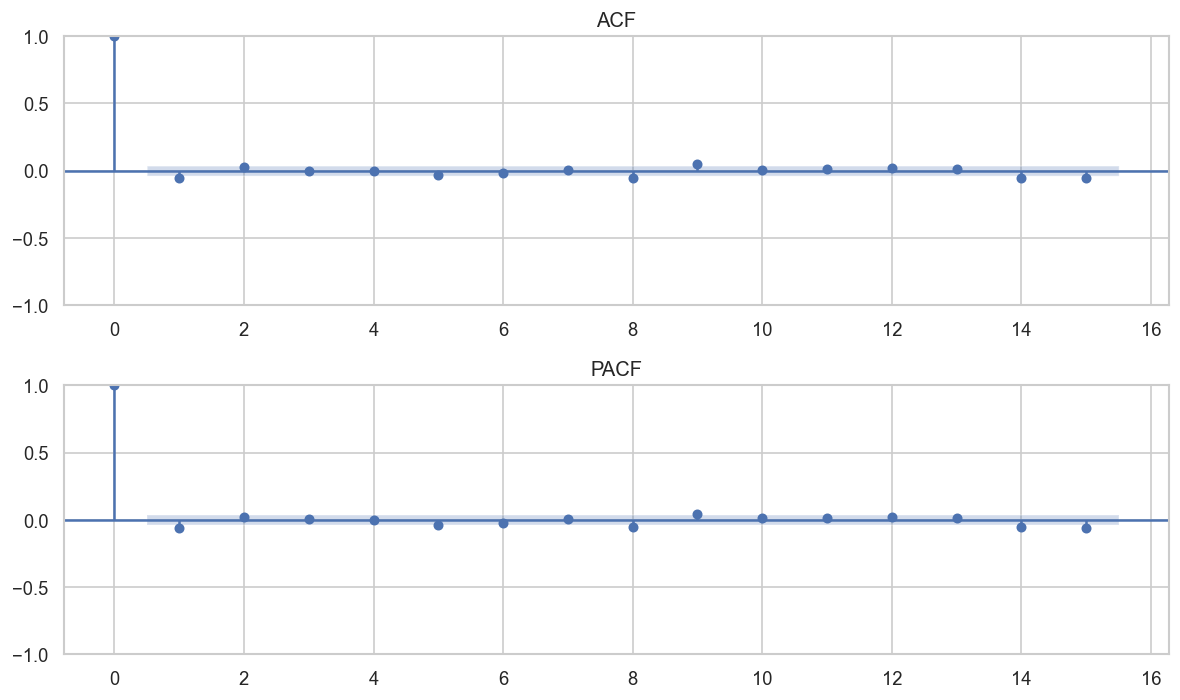

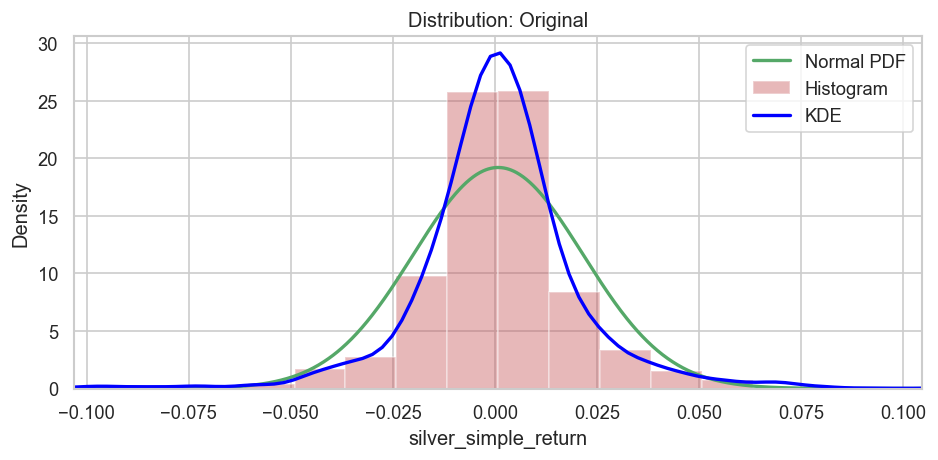

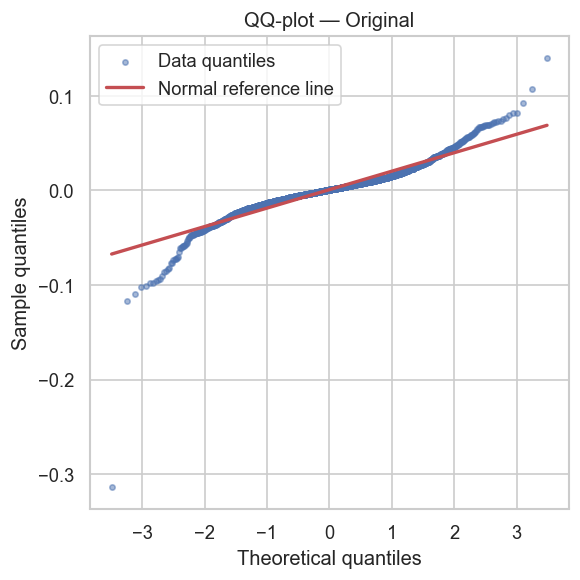

In [ ]:
simple_returns = silver.pct_change().dropna()
simple_returns.name = "silver_simple_return"
result_simple = eda_transform(simple_returns, transform=None, lags=15)

#### Why log returns over simple returns?

To answer the natural question — why not just use `.pct_change()` or `.diff()`?

Say silver closes at **\$16.18** on Monday and **\$16.60** on Tuesday.

| Transform | Formula | Result |
|---|---|---|
| `silver.diff()` | $p_t - p_{t-1} = 16.60 - 16.18$ | $+0.42$ (dollars, not a return) |
| `silver.pct_change()` | $(p_t - p_{t-1})/p_{t-1}$ | $+2.60\%$ (simple return $R_t$) |
| `np.log(silver).diff()` | $\ln(16.60) - \ln(16.18) = \ln(16.60/16.18)$ | $+0.0257$ (log return $r_t$) |

So `.diff()` alone gives a **dollar change**, not a return — it's price-level dependent and useless for comparing across assets or time.

**Why log returns over simple returns?**

1. **Time-additivity.** Suppose silver goes $16 \to 18 \to 15$. Log returns add: $\ln(18/16) + \ln(15/18) = \ln(15/16)$. Simple returns don't: $+12.5\%$ then $-16.7\%$ gives a net of $-6.25\%$, not $-4.17\%$ — you need to multiply $(1.125)(0.833) - 1$, which becomes unwieldy over many periods.

2. **Symmetry.** A price doubling ($r = +\ln 2 \approx +0.693$) and a price halving ($r = -\ln 2 \approx -0.693$) are equal in magnitude. In simple return space they are not: $+100\%$ up vs $-50\%$ down.

3. **Approximate normality.** Log returns are closer to Gaussian for daily horizons, which is what ARIMA and OLS assume. Price levels and dollar differences are non-stationary by construction.

For small daily moves $r_t \approx R_t$ (first-order Taylor: $\ln(1+R_t) \approx R_t$), so the two are nearly identical numerically day-to-day — the differences accumulate over longer horizons.

**A note on variance stability.** `.diff()` is also stationary and would show similar autocorrelation structure in the ACF — so stationarity alone doesn't justify the log transform. The variance-stabilisation argument (a \$0.42 move at \$16 vs \$25) is real but modest for silver's price range (\$14–\$30). The most defensible justification here is **convention**: log returns are the field default in financial econometrics, and what ARIMA/OLS residual assumptions are built around.

> **TODO:** Run a Levene or Bartlett test comparing variance stability of `silver.diff()` vs `np.log(silver).diff()` across subperiods (pre/post 2020, pre/post silver squeeze) to quantify whether the variance-stabilisation argument actually holds for this sample.

#### Log returns (`np.log().diff()`) — model input

No transform applied.


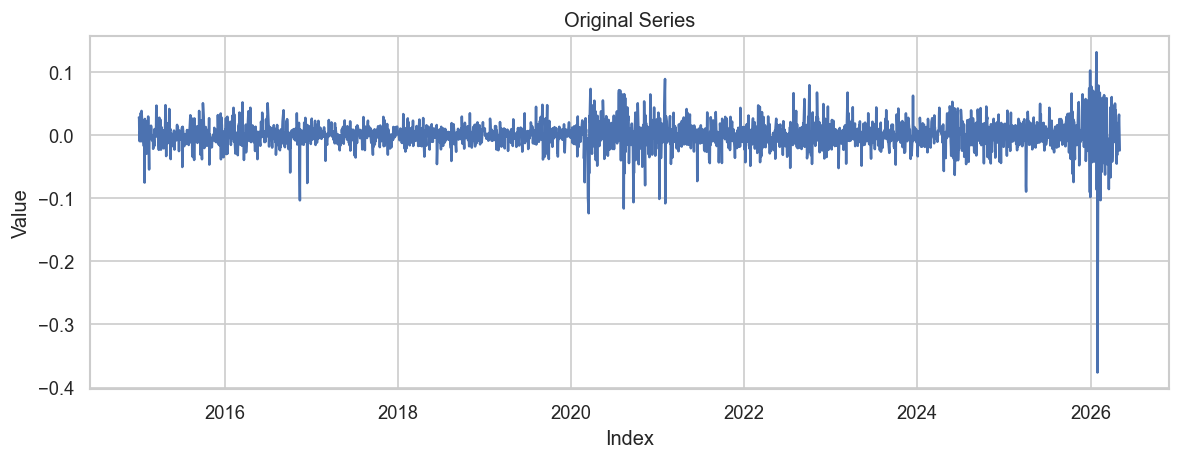

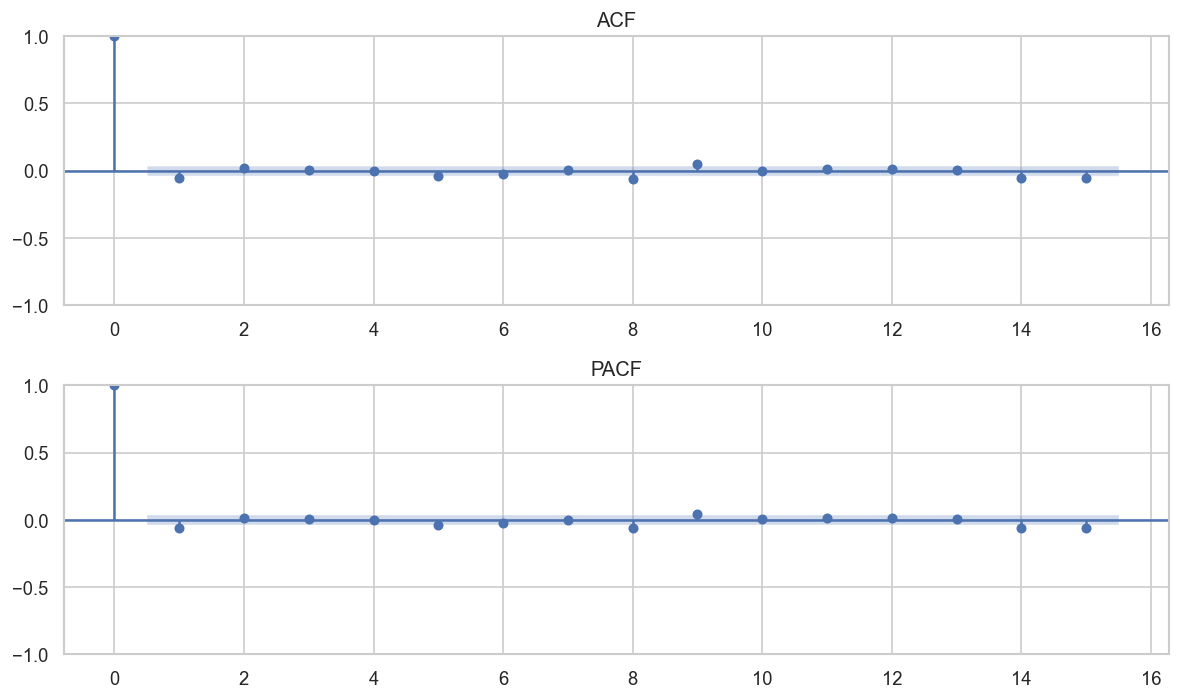

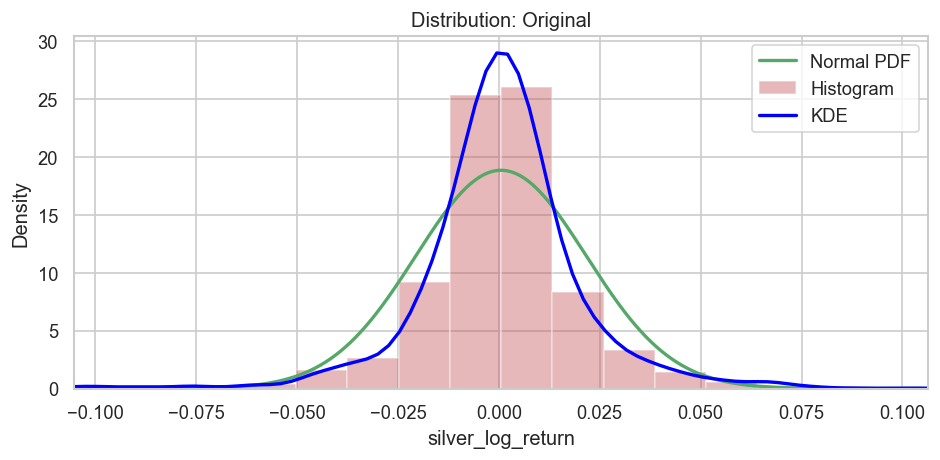

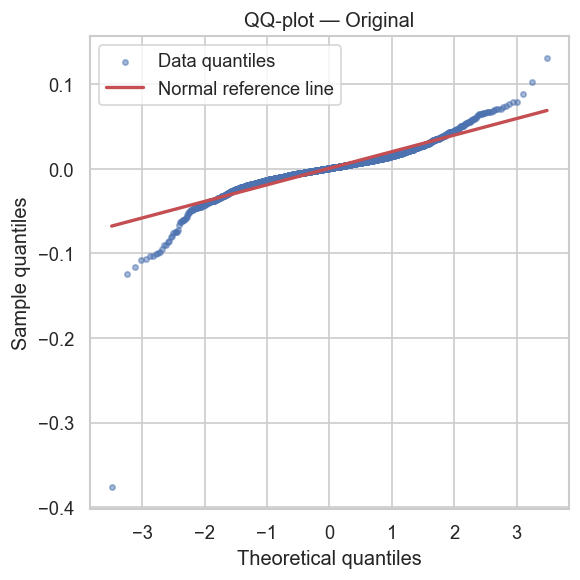

  QQ R²: 0.8542 (1.0 = perfect normal)

ADF Test:
  Statistic: -9.4869
  p-value:   0.0000
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Stationary (reject H₀)

Ljung-Box:
  lag=5: p-value = 0.0130  → Autocorrelation present
  lag=10: p-value = 0.0002  → Autocorrelation present
  lag=20: p-value = 0.0000  → Autocorrelation present
  lag=60: p-value = 0.0000  → Autocorrelation present

Shapiro-Wilk:         stat=0.8572, p=0.0000  → NOT normal
D'Agostino K²:        stat=1846.3017, p=0.0000  → NOT normal
Anderson-Darling:     stat=64.7974
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.0974, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=135.80, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared residuals:
  lag=5: p-value = 0.0000  → ARCH effects likely
  lag=10: p-value = 0.0000  → A

/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:119: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [ ]:
log_returns = np.log(silver).diff().dropna()
log_returns.name = 'silver_log_return'
result_returns = eda_transform(log_returns, transform=None, lags=15)

#### Weekly log returns (5-day sum) — model input at weekly frequency

The models in `weekly/` operate on `resample('W-FRI').sum()` of daily log-returns. `eda_transform` below runs the same diagnostics as above on this aggregated series; a Ljung-Box test then formally checks for remaining serial correlation.

Weekly observations: 592
No transform applied.


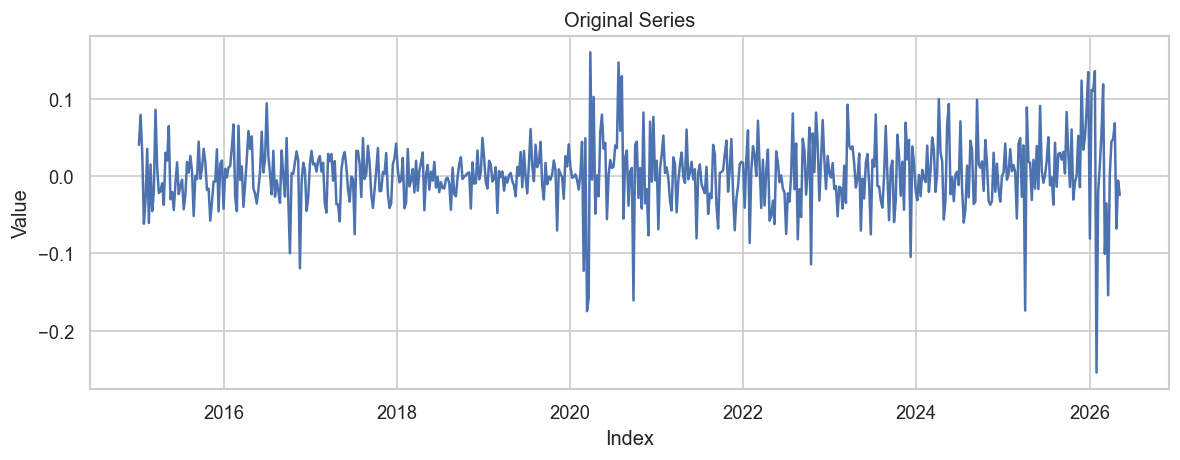

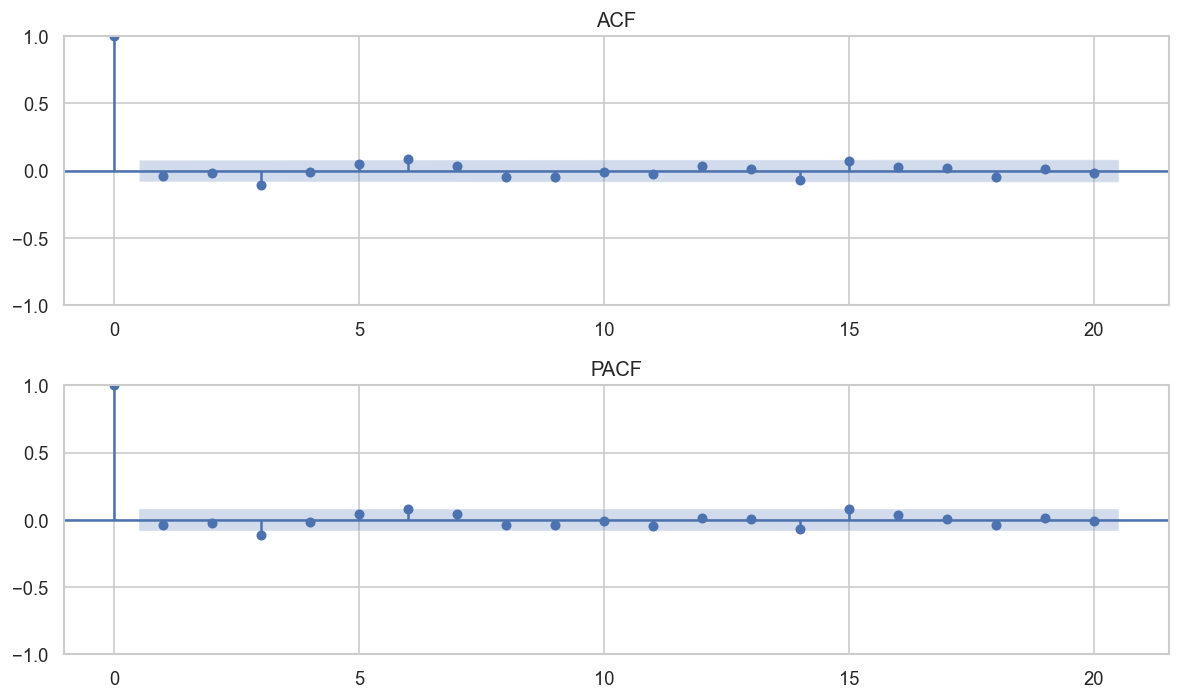

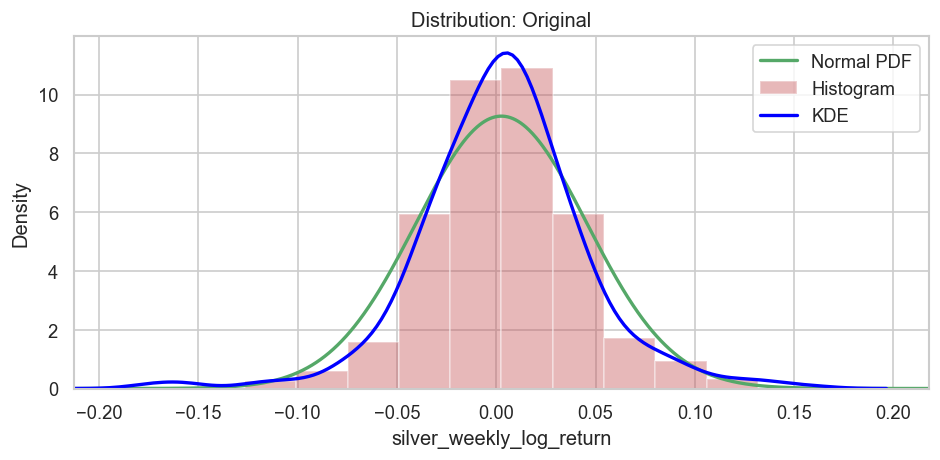

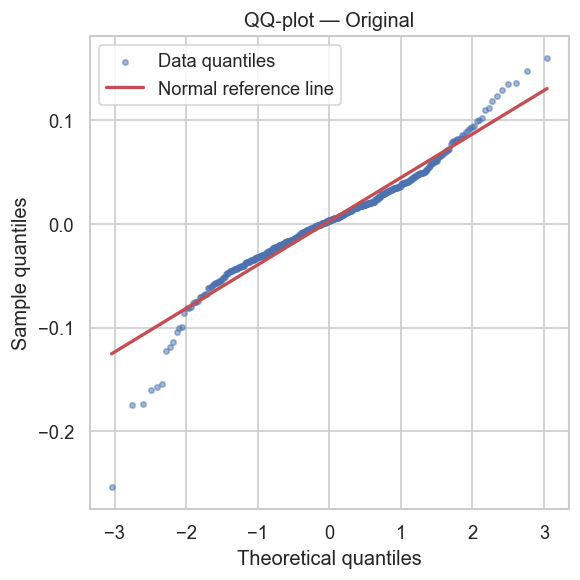

  QQ R²: 0.9461 (1.0 = perfect normal)

ADF Test:
  Statistic: -16.1387
  p-value:   0.0000
    1%: -3.4415
    5%: -2.8665
    10%: -2.5694
  → Stationary (reject H₀)

Ljung-Box:
  lag=2: p-value = 0.5641  → No significant autocorrelation
  lag=4: p-value = 0.0801  → No significant autocorrelation
  lag=8: p-value = 0.0364  → Autocorrelation present
  lag=13: p-value = 0.1152  → No significant autocorrelation

Shapiro-Wilk:         stat=0.9494, p=0.0000  → NOT normal
D'Agostino K²:        stat=84.2637, p=0.0000  → NOT normal
Anderson-Darling:     stat=5.3926
     15.0%: 0.5600 ← reject normality
     10.0%: 0.6300 ← reject normality
      5.0%: 0.7510 ← reject normality
      2.5%: 0.8720 ← reject normality
      1.0%: 1.0340 ← reject normality
Kolmogorov-Smirnov:   stat=0.0645, p=0.0139  → NOT normal

ARCH LM test (nlags=12):  stat=83.14, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared residuals:
  lag=2: p-value = 0.0000  → ARCH effects likely
  lag=4: p-valu

/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:119: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Aggregate daily log-returns to weekly (Mon–Fri sum)
silver_weekly = log_returns.resample('W-FRI').sum().dropna()
print(f'Weekly observations: {len(silver_weekly)}')

silver_weekly.name = 'silver_weekly_log_return'
result_weekly = eda_transform(silver_weekly, transform=None, lags=20)

# Ljung-Box: formal test for remaining serial correlation
lb = acorr_ljungbox(silver_weekly, lags=[5, 10, 20], return_df=True)
print('\nLjung-Box test (weekly returns):')
print(lb.to_string())

### Key finding: weekly silver returns are white noise

The ACF/PACF plots above show every spike well within the 95% confidence bands at all lags,
and the Ljung-Box test returns p = 0.358 — no statistically significant autocorrelation
at any horizon up to lag 20. The AIC grid search in `03_arima_baseline.ipynb` confirms
this by selecting **ARIMA(0,0,0)** — a constant mean with white noise — as the best model.

**What this means:**

Weekly silver log-returns have no memory of their own past. Knowing last week's return
tells you nothing about this week's return. This is consistent with the **weak form of
the Efficient Market Hypothesis** (EMH): all information contained in past prices is
already reflected in the current price.

**Why this is central to the thesis:**

If silver returns cannot be predicted from their own history, any predictive power must
come from *external* information. This motivates the two main ingredients of the thesis:

1. **Market co-movements** (gold, USD, copper, S&P500 via ARIMAX and MIDAS) — do
   related asset returns contain information about next week's silver return?
2. **Retail sentiment** (Reddit via RoBERTa, news via FinBERT) — does the mood of
   retail traders provide a leading signal beyond what market variables already capture?

If sentiment adds directional accuracy on top of the ARIMAX baseline, that is evidence
against **semi-strong EMH** — public sentiment data is not fully priced in at weekly
frequency. This would support the retail-driven price hypothesis central to this thesis.


## 5. Covariate overview

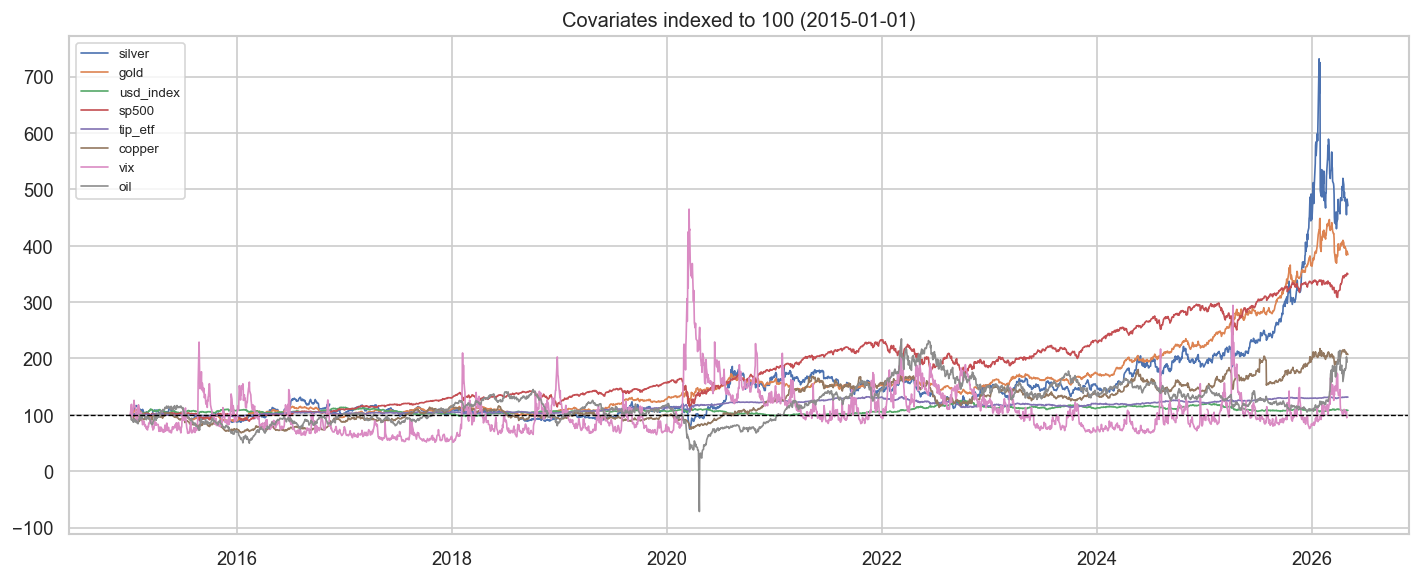

In [ ]:
# Plot all daily covariates normalised to 100 at start
norm_prices = prices.div(prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in norm_prices.columns:
    ax.plot(norm_prices[col], label=col, lw=1)
ax.axhline(100, color='black', lw=0.8, linestyle='--')
ax.set_title('Covariates indexed to 100 (2015-01-01)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation matrix

Three views: same-day (contemporaneous), 1-day lagged, and 1-week lagged correlations with silver returns. Sentiment columns are added to the lagged matrices when `03_sentiment.ipynb` has been run.

Sentiment added.


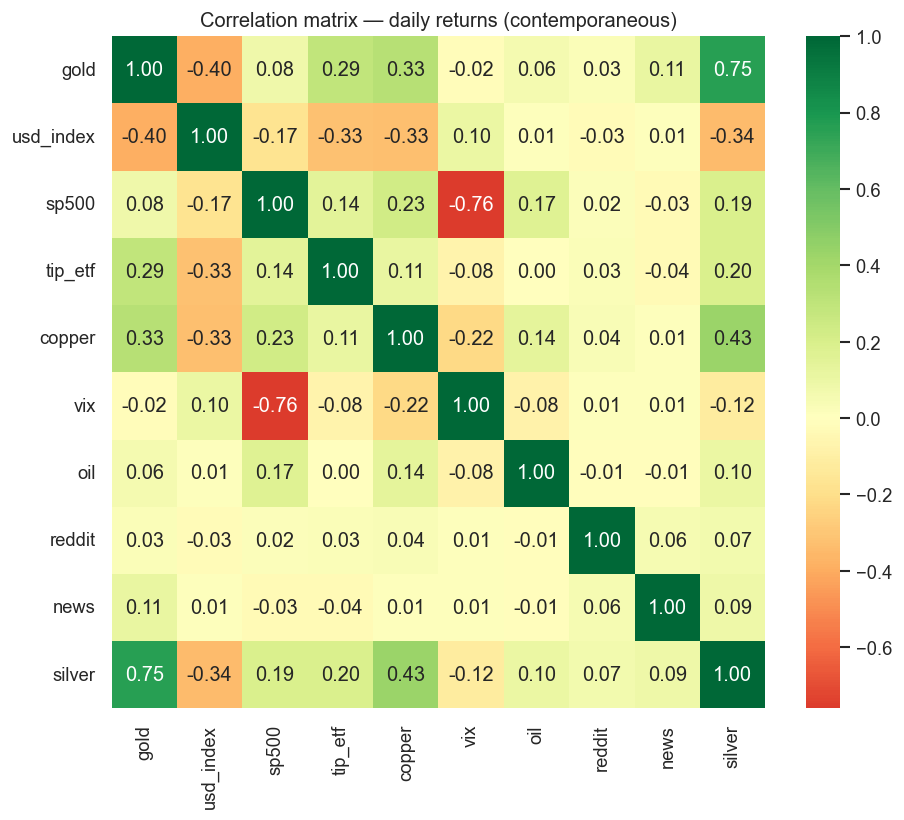

In [ ]:
returns = prices.pct_change().dropna()

# Silver last; optionally add same-day sentiment
cols = [c for c in returns.columns if c != 'silver']
base_df_c = returns[cols].copy()

sent_path = '../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent_d = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    base_df_c = base_df_c.join(
        sent_d[['reddit_sentiment', 'news_sentiment']].rename(columns={
            'reddit_sentiment': 'reddit',
            'news_sentiment':   'news',
        }), how='left')
    print('Sentiment added.')
else:
    print('No sentiment file — run 03_sentiment.ipynb to include it.')

base_df_c['silver'] = returns['silver']

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(base_df_c.dropna().corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax)
ax.set_title('Correlation matrix — daily returns (contemporaneous)')
plt.tight_layout()
plt.show()


**Daily, 1-day lag** — does yesterday's return of each asset (and sentiment) predict today's silver return?

Sentiment added.


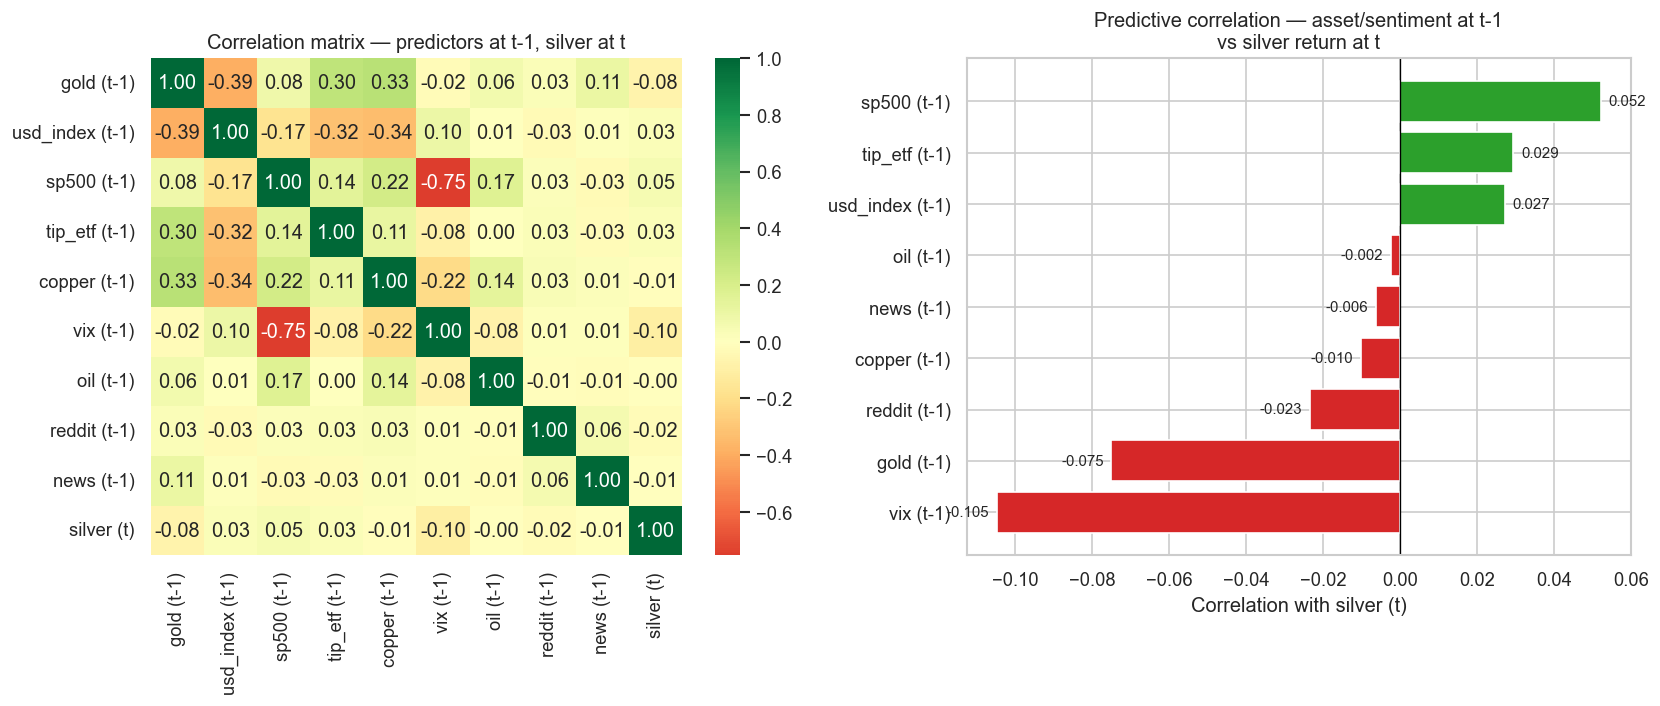


Predictive correlations with silver return at t (predictors at t-1):
vix (t-1)         -0.104843
gold (t-1)        -0.075024
reddit (t-1)      -0.023368
copper (t-1)      -0.010169
news (t-1)        -0.006233
oil (t-1)         -0.002419
usd_index (t-1)    0.027314
tip_etf (t-1)      0.029421
sp500 (t-1)        0.052190


In [ ]:
# 1-day lagged correlation: all predictors shifted back 1 day, silver at t last
other_cols = [c for c in returns.columns if c != 'silver']
lagged = returns[other_cols].shift(1).rename(columns=lambda c: f'{c} (t-1)')

# Optionally add daily sentiment (lagged by 1 day)
sent_path = '../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent_d = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_d_lag = sent_d[['reddit_sentiment', 'news_sentiment']].shift(1).rename(columns={
        'reddit_sentiment': 'reddit (t-1)',
        'news_sentiment':   'news (t-1)',
    })
    lagged = lagged.join(sent_d_lag, how='left')
    print('Sentiment added.')
else:
    print('No sentiment file — run 03_sentiment.ipynb to include it.')

# Silver at t always last
lagged['silver (t)'] = returns['silver']

lag_corr = lagged.dropna().corr()

predictors = [c for c in lag_corr.columns if c != 'silver (t)']
lag_row = lag_corr.loc[predictors, 'silver (t)'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(predictors) * 0.45 + 2)))

sns.heatmap(lag_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Correlation matrix — predictors at t-1, silver at t')

colors = ['#d62728' if v < 0 else '#2ca02c' for v in lag_row.values]
axes[1].barh(lag_row.index, lag_row.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with silver (t)')
axes[1].set_title('Predictive correlation — asset/sentiment at t-1\nvs silver return at t')
for v, name in zip(lag_row.values, lag_row.index):
    axes[1].text(v + 0.002 * (1 if v >= 0 else -1), name, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nPredictive correlations with silver return at t (predictors at t-1):')
print(lag_row.to_string())


**Weekly, 1-week lag** — same question at weekly frequency; sentiment resampled to weekly and lagged by one week.

Sentiment added to correlation matrix.


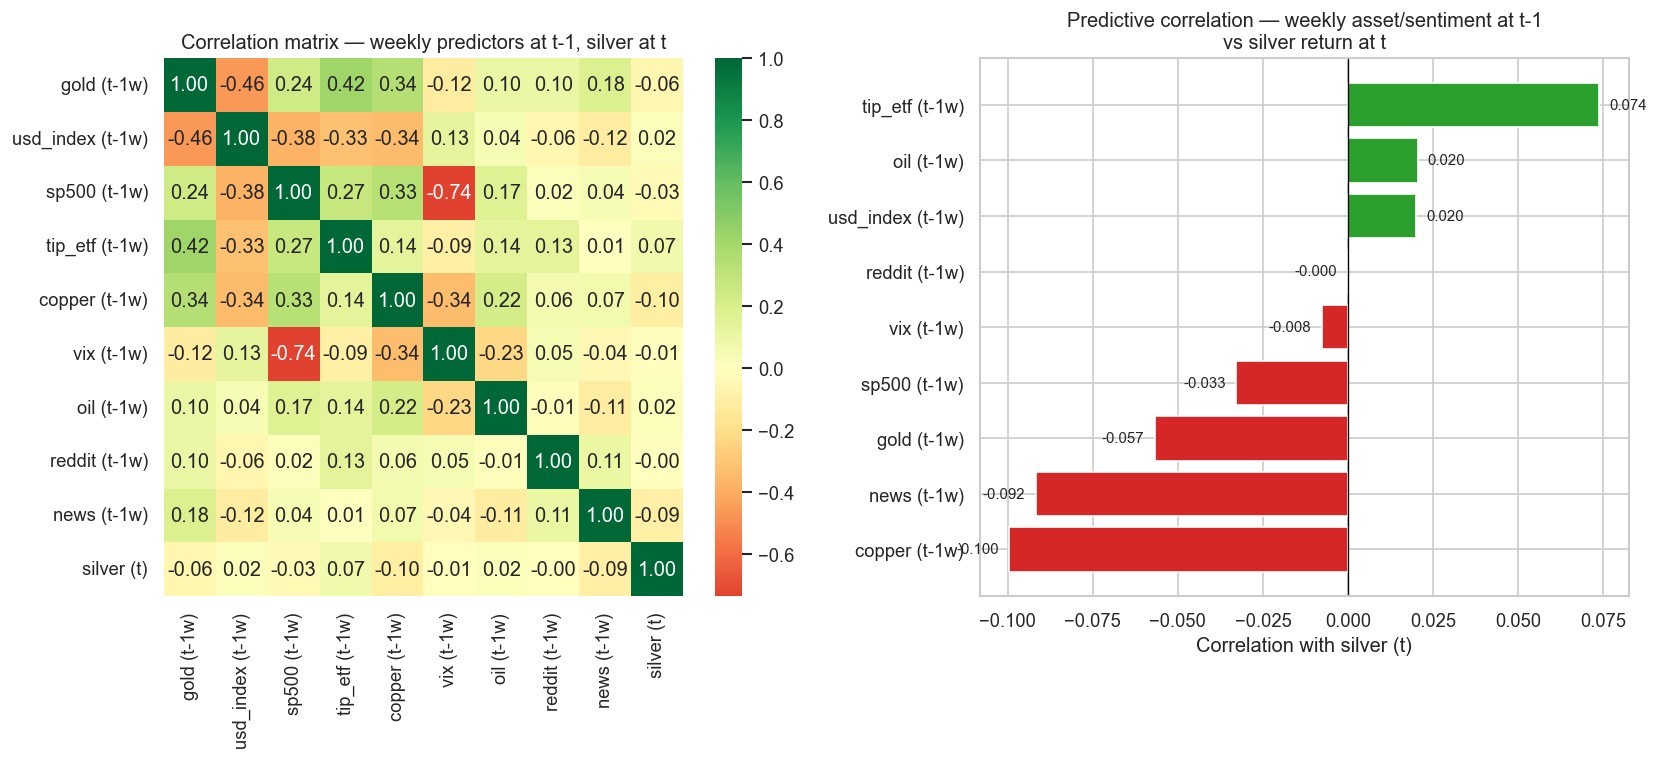


1-week predictive correlations with silver return at t (predictors at t-1w):
copper (t-1w)      -0.099585
news (t-1w)        -0.091805
gold (t-1w)        -0.056862
sp500 (t-1w)       -0.032957
vix (t-1w)         -0.007788
reddit (t-1w)      -0.000129
usd_index (t-1w)    0.020066
oil (t-1w)          0.020462
tip_etf (t-1w)      0.073860


In [ ]:
import os

# 1-week lagged correlation: all predictors shifted back 1 week, silver at t last
returns_w = prices.resample('W-FRI').last().pct_change().dropna()

other_cols_w = [c for c in returns_w.columns if c != 'silver']
lagged_w = returns_w[other_cols_w].shift(1).rename(columns=lambda c: f'{c} (t-1w)')

# Optionally add sentiment (weekly, lagged by 1 week)
sent_path = '../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[['reddit_sentiment', 'news_sentiment']].resample('W-FRI').mean()
    sent_w_lag = sent_w.shift(1).rename(columns={
        'reddit_sentiment': 'reddit (t-1w)',
        'news_sentiment':   'news (t-1w)',
    })
    lagged_w = lagged_w.join(sent_w_lag, how='left')
    print('Sentiment added to correlation matrix.')
else:
    print('No sentiment file — run 03_sentiment.ipynb to include it.')

# Silver at t always last
lagged_w['silver (t)'] = returns_w['silver']

lag_corr_w = lagged_w.dropna().corr()

predictors_w = [c for c in lag_corr_w.columns if c != 'silver (t)']
lag_row_w = lag_corr_w.loc[predictors_w, 'silver (t)'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(predictors_w) * 0.5 + 2)))

sns.heatmap(lag_corr_w, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0])
axes[0].set_title('Correlation matrix — weekly predictors at t-1, silver at t')

colors = ['#d62728' if v < 0 else '#2ca02c' for v in lag_row_w.values]
axes[1].barh(lag_row_w.index, lag_row_w.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with silver (t)')
axes[1].set_title('Predictive correlation — weekly asset/sentiment at t-1\nvs silver return at t')
for v, name in zip(lag_row_w.values, lag_row_w.index):
    axes[1].text(v + 0.003 * (1 if v >= 0 else -1), name, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\n1-week predictive correlations with silver return at t (predictors at t-1w):')
print(lag_row_w.to_string())


## 7. Gold/Silver ratio

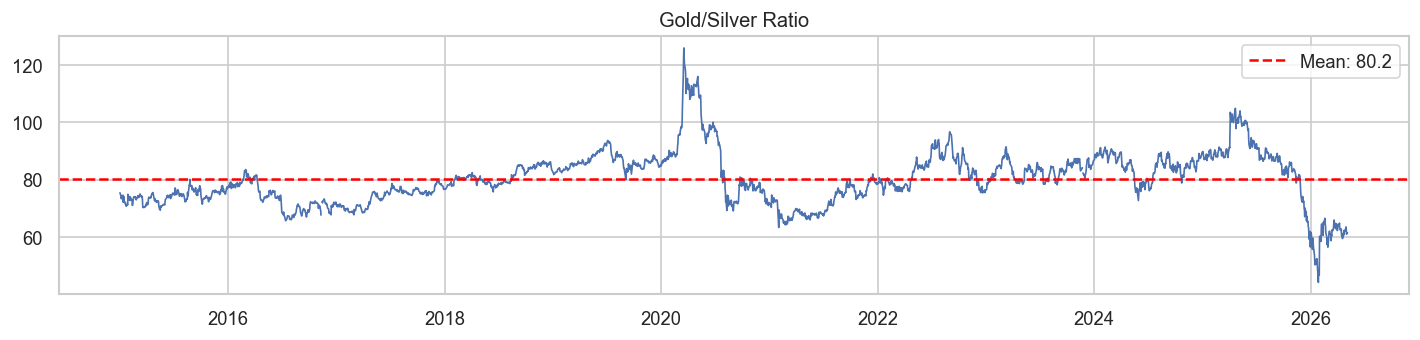

No transform applied.


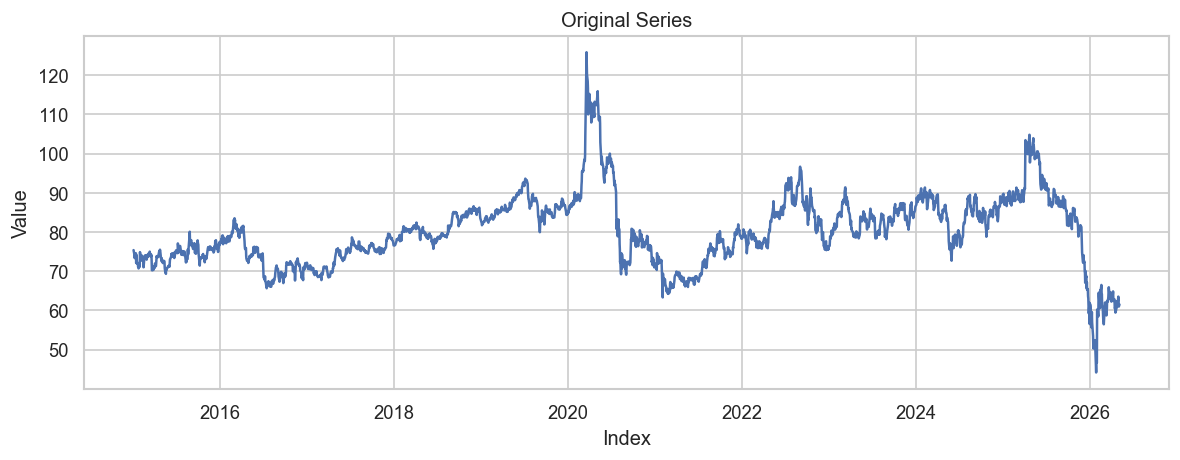

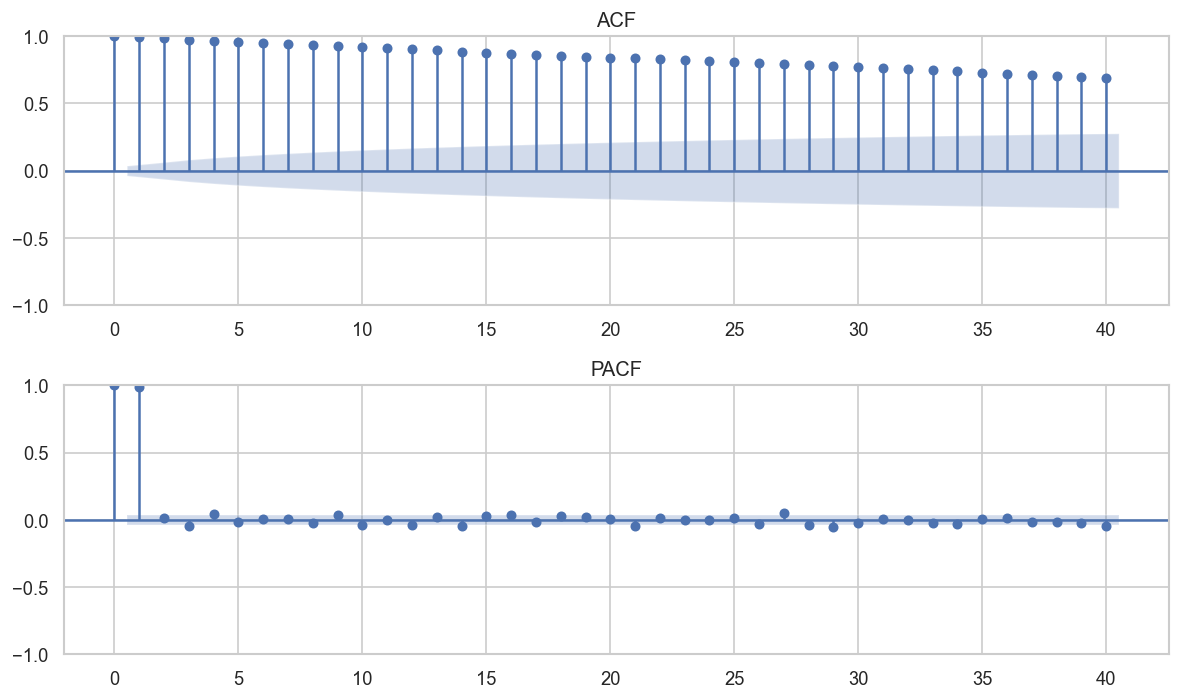

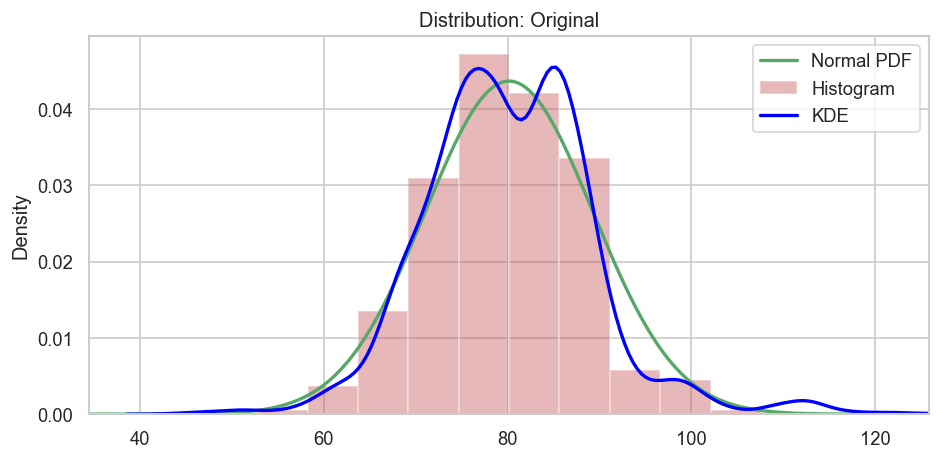

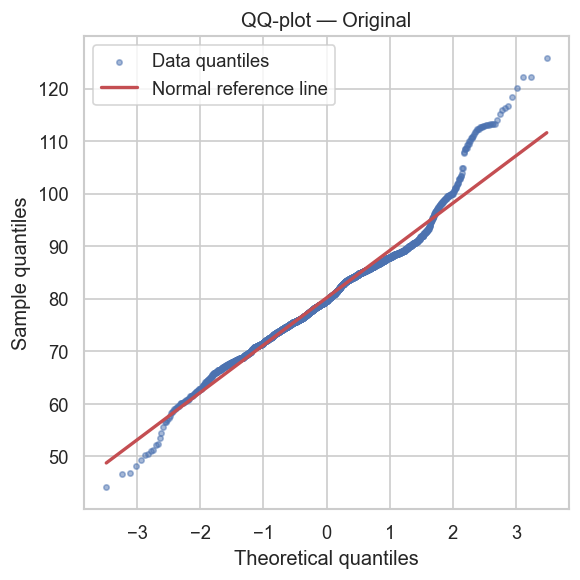

  QQ R²: 0.9707 (1.0 = perfect normal)

ADF Test:
  Statistic: -3.0327
  p-value:   0.0320
    1%: -3.4327
    5%: -2.8626
    10%: -2.5673
  → Stationary (reject H₀)

Ljung-Box:
  lag=5: p-value = 0.0000  → Autocorrelation present
  lag=10: p-value = 0.0000  → Autocorrelation present
  lag=20: p-value = 0.0000  → Autocorrelation present
  lag=60: p-value = 0.0000  → Autocorrelation present

Shapiro-Wilk:         stat=0.9711, p=0.0000  → NOT normal
D'Agostino K²:        stat=245.6765, p=0.0000  → NOT normal
Anderson-Darling:     stat=12.1107
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.0552, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2709.27, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared residuals:
  lag=5: p-value = 0.0000  → ARCH effects likely
  lag=10: p-value = 0.0000  → A

/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:119: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

{'transformed_series': Date
 2015-01-02    75.378161
 2015-01-05    74.411271
 2015-01-06    73.438535
 2015-01-07    73.325255
 2015-01-08    73.903739
                 ...    
 2026-04-28    62.721124
 2026-04-29    63.507946
 2026-04-30    62.756010
 2026-05-01    60.959041
 2026-05-04    61.486580
 Length: 2849, dtype: float64,
 'adf': {'stat': -3.0326666903606085,
  'pvalue': 0.03195432022014485,
  'crit': {'1%': -3.4326710150605764,
   '5%': -2.862565463281347,
   '10%': -2.5673158851415923}},
 'ljung_box':           lb_stat  lb_pvalue
 5    13569.823040        0.0
 10   26065.255096        0.0
 20   48011.710387        0.0
 60  103425.708266        0.0,
 'ljung_box_sq':          lb_stat  lb_pvalue
 5   12040.402912        0.0
 10  21270.768262        0.0
 20  33834.747613        0.0
 60  48896.820303        0.0,
 'shapiro': {'stat': 0.9711130730771372, 'pvalue': 1.5374462470552865e-23}}

In [ ]:
gs_ratio = prices['gold'] / prices['silver']

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gs_ratio, lw=1)
ax.axhline(gs_ratio.mean(), color='red', linestyle='--', label=f'Mean: {gs_ratio.mean():.1f}')
ax.set_title('Gold/Silver Ratio')
ax.legend()
plt.tight_layout()
plt.show()

# ADF on G/S ratio — often mean-reverting
eda_transform(gs_ratio.dropna(), transform=None, lags=40)

## 8. Mixed-frequency visualisation (MIDAS motivation)

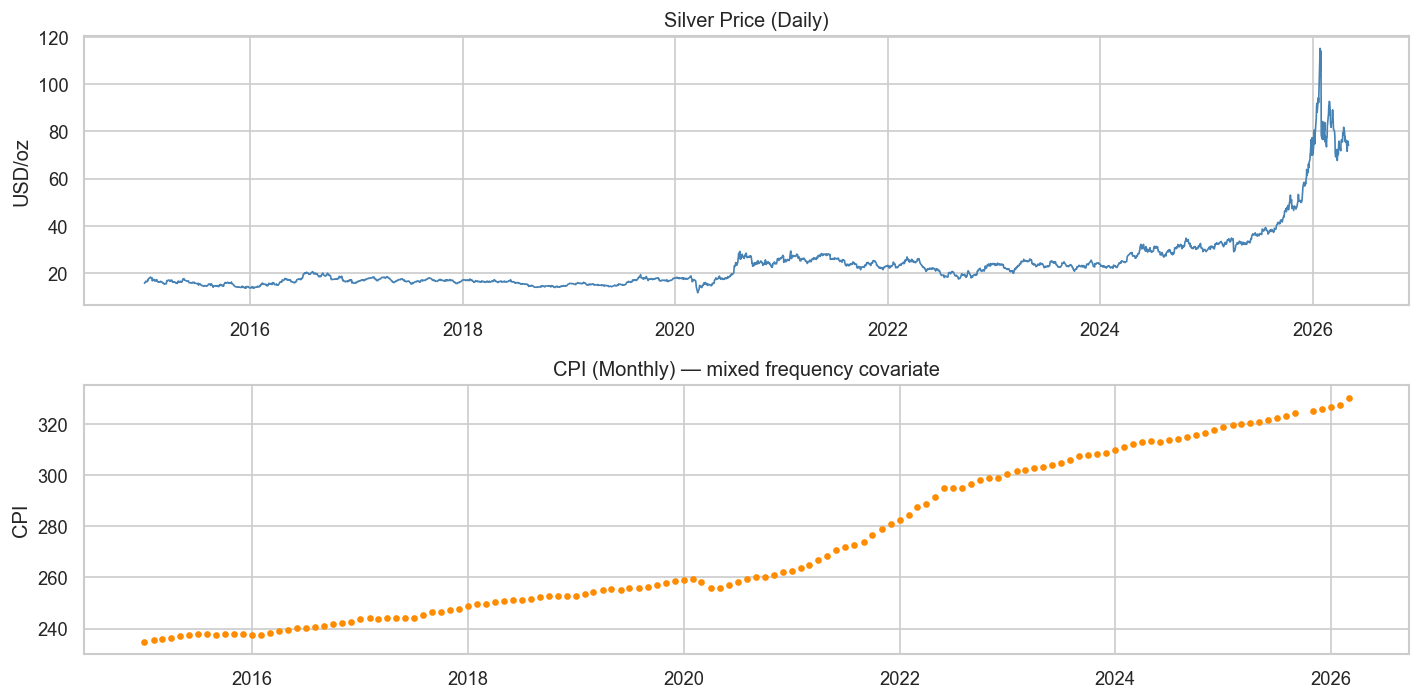

Daily obs: 2849 | Monthly obs: 2991


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

ax1.plot(silver, lw=1, color='steelblue')
ax1.set_title('Silver Price (Daily)')
ax1.set_ylabel('USD/oz')

if 'cpi' in macro.columns:
    ax2.plot(macro['cpi'], marker='o', markersize=3, lw=1, color='darkorange')
    ax2.set_title('CPI (Monthly) — mixed frequency covariate')
    ax2.set_ylabel('CPI')

plt.tight_layout()
plt.show()
print('Daily obs:', len(silver), '| Monthly obs:', len(macro))

## 9. Google Trends — retail attention vs silver returns

Google Trends measures how many people searched for "silver", "buy silver" and
"silver price" each week. Unlike Reddit/news sentiment (expressed opinion), Trends
captures *attention* — people actively seeking out silver information.

Tested at two lags:
- **1-week lag**: last week's search interest vs this week's return
- **4-week lag**: search interest a month ago vs current return

Two windows: **full sample** (2015–2026) and the **squeeze episode** (Oct 2020–Jun 2021).

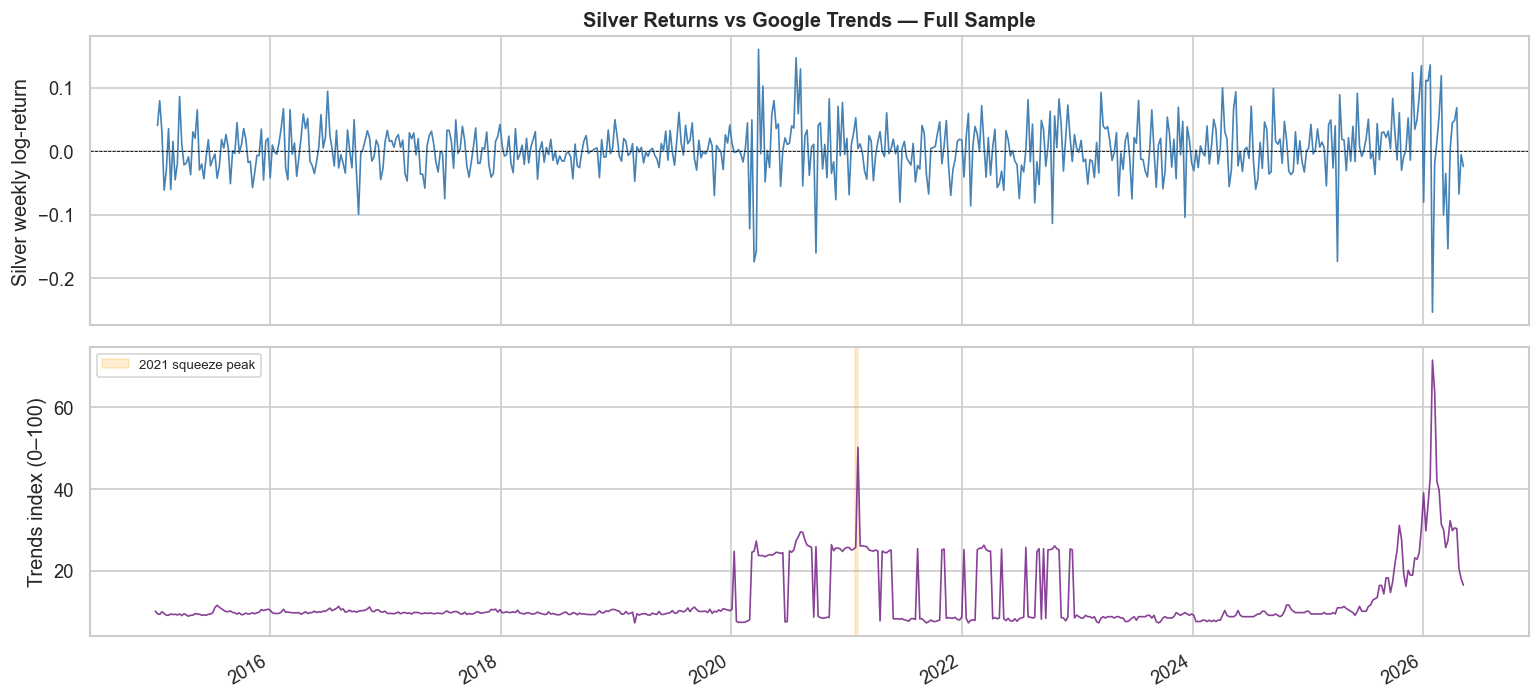

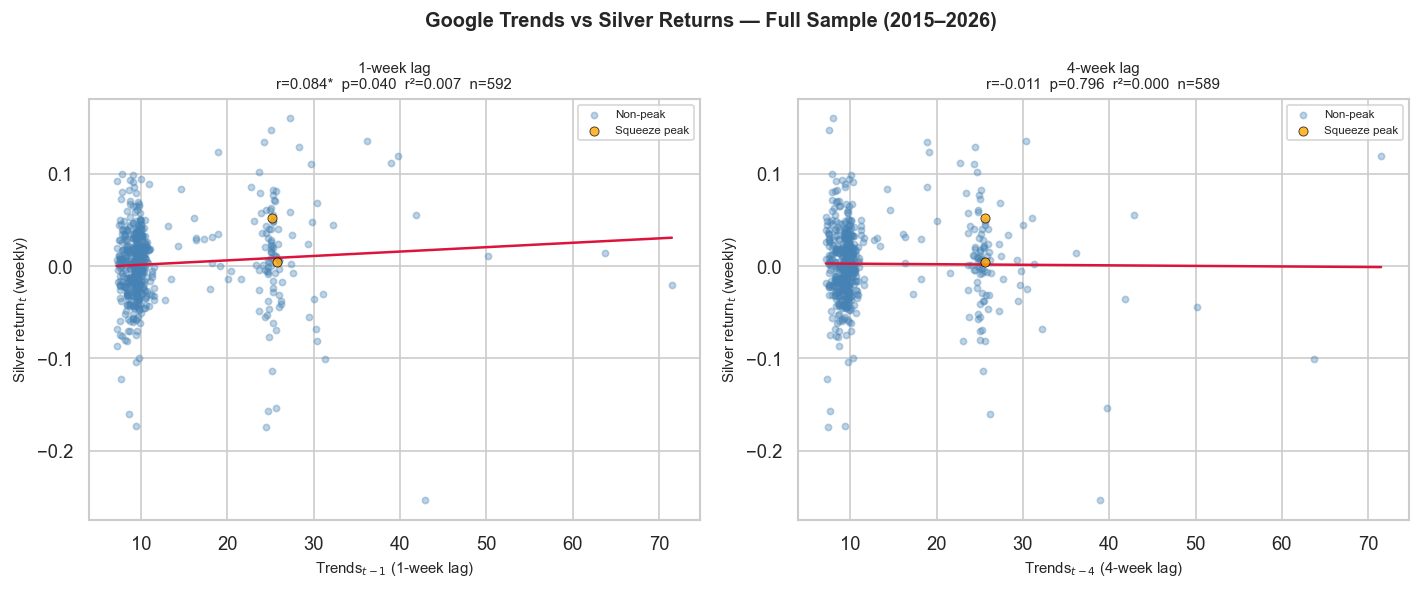

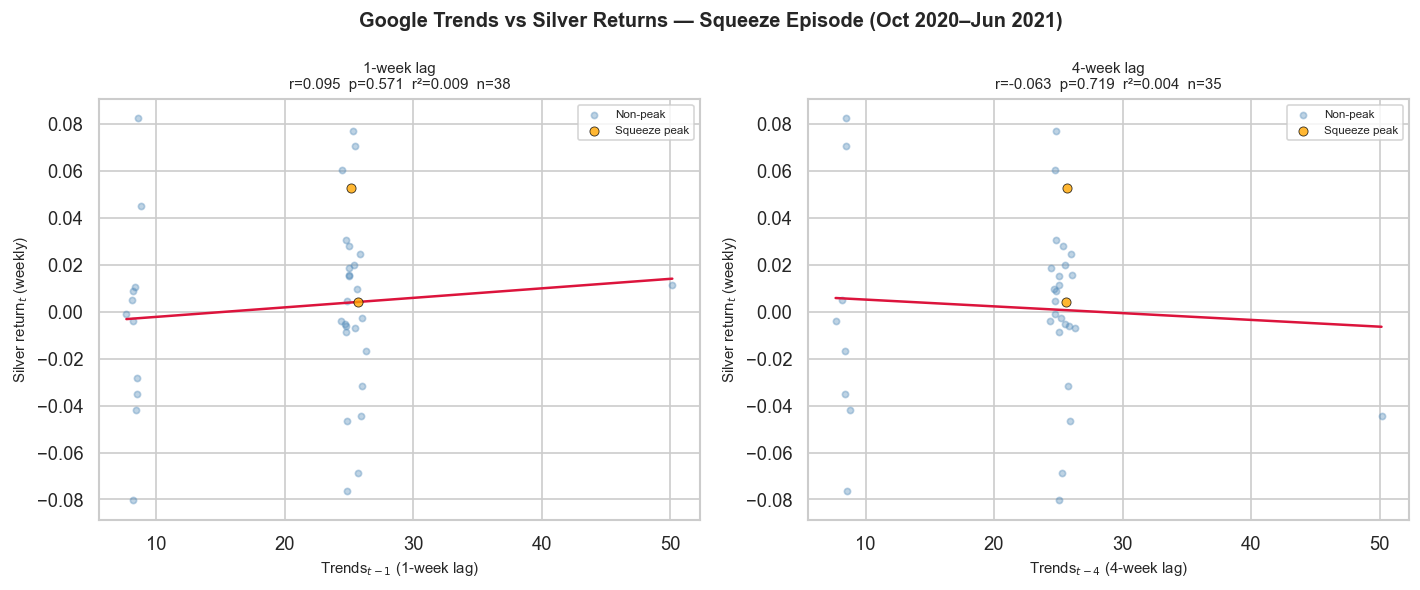


Summary — Google Trends correlations:
  Window               Specification              r       r²        p
  --------------------------------------------------------------
  Full sample          1-week lag             0.084    0.007    0.040*
  Full sample          4-week lag            -0.011    0.000    0.796
  Squeeze episode      1-week lag             0.095    0.009    0.571
  Squeeze episode      4-week lag            -0.063    0.004    0.719

* p<0.05  ** p<0.01  *** p<0.001

If Trends correlates but Reddit/News do not → event was attention-driven, not sentiment-driven.


In [ ]:
from scipy import stats as scipy_stats

trends_path = '../data/raw/google_trends.csv'
if not os.path.exists(trends_path):
    print('google_trends.csv not found — run src/collect_trends.py first.')
else:
    trends = pd.read_csv(trends_path, index_col=0, parse_dates=True)
    trends.index = trends.index.tz_localize(None)

    # Compute weekly silver log-returns (prices loaded in section 1)
    silver_ret = np.log(prices['silver']).diff().dropna()
    silver_ret_w = silver_ret.resample('W-FRI').sum()

    # Align Trends to same weekly grid
    trends_w = trends['trends_silver'].resample('W-FRI').mean()

    # Squeeze peak window for scatter colour-coding
    SQUEEZE_START = pd.Timestamp('2021-01-28')
    SQUEEZE_END   = pd.Timestamp('2021-02-05')

    # ── Scatter helper ────────────────────────────────────────────────────
    def trends_scatter(ax, x_series, y_series, xlabel, ylabel, title):
        df = pd.concat([x_series, y_series], axis=1).dropna()
        if len(df) < 10:
            ax.text(0.5, 0.5, f'n={len(df)} — insufficient', ha='center',
                    va='center', transform=ax.transAxes)
            ax.set_title(title); return None
        x, y = df.iloc[:, 0].values, df.iloc[:, 1].values
        r, p = scipy_stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        peak_mask = (df.index >= SQUEEZE_START) & (df.index <= SQUEEZE_END)
        ax.scatter(x[~peak_mask], y[~peak_mask], alpha=0.35, s=14,
                   color='steelblue', label='Non-peak')
        ax.scatter(x[peak_mask], y[peak_mask], alpha=0.8, s=30,
                   color='orange', edgecolors='black', lw=0.5,
                   zorder=5, label='Squeeze peak')
        ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        r2 = r ** 2
        ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  r²={r2:.3f}  n={len(df)}',
                     fontsize=9)
        ax.legend(fontsize=7)
        return {'title': title, 'r': r, 'r2': r2, 'p': p, 'n': len(df)}

    # ── Panel 1: time series — Trends vs silver returns (full sample) ─────
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

    ax1, ax2 = axes
    ax1.plot(silver_ret_w.index, silver_ret_w.values, lw=1, color='steelblue')
    ax1.axhline(0, color='black', lw=0.5, ls='--')
    ax1.set_ylabel('Silver weekly log-return')
    ax1.set_title('Silver Returns vs Google Trends — Full Sample', fontweight='bold')

    ax2.plot(trends_w.index, trends_w.values, lw=1, color='#7b2d8b', alpha=0.9)
    ax2.set_ylabel('Trends index (0–100)')
    ax2.axvspan(SQUEEZE_START, SQUEEZE_END, alpha=0.18, color='orange',
                label='2021 squeeze peak')
    ax2.legend(fontsize=8)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # ── Panel 2: scatter — full sample ───────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Google Trends vs Silver Returns — Full Sample (2015–2026)',
                 fontsize=12, fontweight='bold')

    results_trends = []
    for ax, lag, lag_label in [
        (axes[0], 1, '1-week lag'),
        (axes[1], 4, '4-week lag'),
    ]:
        r = trends_scatter(ax,
            trends_w.shift(lag),
            silver_ret_w.reindex(trends_w.index),
            f'Trends$_{{t-{lag}}}$ ({lag_label})',
            'Silver return$_t$ (weekly)',
            lag_label)
        if r:
            r['window'] = 'Full sample'
            results_trends.append(r)

    plt.tight_layout()
    plt.show()

    # ── Panel 3: scatter — squeeze episode only ───────────────────────────
    EPISODE_START = '2020-10-01'
    EPISODE_END   = '2021-06-30'
    ret_ep_w    = silver_ret_w.loc[EPISODE_START:EPISODE_END]
    trends_ep_w = trends_w.loc[EPISODE_START:EPISODE_END]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Google Trends vs Silver Returns — Squeeze Episode (Oct 2020–Jun 2021)',
                 fontsize=12, fontweight='bold')

    for ax, lag, lag_label in [
        (axes[0], 1, '1-week lag'),
        (axes[1], 4, '4-week lag'),
    ]:
        r = trends_scatter(ax,
            trends_ep_w.shift(lag),
            ret_ep_w.reindex(trends_ep_w.index),
            f'Trends$_{{t-{lag}}}$ ({lag_label})',
            'Silver return$_t$ (weekly)',
            lag_label)
        if r:
            r['window'] = 'Squeeze episode'
            results_trends.append(r)

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────
    if results_trends:
        print('\nSummary — Google Trends correlations:')
        print(f'  {"Window":<20} {"Specification":<20} {"r":>7}  {"r²":>7}  {"p":>7}')
        print('  ' + '-' * 62)
        for row in results_trends:
            sig = '***' if row["p"] < 0.001 else '**' if row["p"] < 0.01 else '*' if row["p"] < 0.05 else ''
            print(f'  {row["window"]:<20} {row["title"]:<20} {row["r"]:>7.3f}  {row["r2"]:>7.3f}  {row["p"]:>7.3f}{sig}')
        print('\n* p<0.05  ** p<0.01  *** p<0.001')
        print('\nIf Trends correlates but Reddit/News do not → event was attention-driven, not sentiment-driven.')

## 10. Sentiment analysis

Loads `daily_sentiment.csv` produced by `03_sentiment.ipynb`.
Cells below are skipped gracefully if the file does not exist yet.

## Chart notes — Silver Price vs Daily Sentiment Index

**Data sources**
- r/Silverbugs: active since ~2012, long-term stackers and precious metals collectors. Collected from 2015 onwards in this dataset.
- r/WallStreetSilver: created **28 January 2021**, the day the WallStreetBets crowd pivoted from GameStop to silver. First post in this dataset: 27 February 2021.

**What the chart shows**

- **2015–2019**: sentiment is moderate and stable, dominated entirely by Silverbugs. The community is small and consistently bullish but not extreme.
- **2020**: sentiment becomes more volatile — COVID uncertainty, stimulus money, and the beginning of retail interest in hard assets.
- **2021 onwards**: WallStreetSilver enters the dataset. Sentiment spikes sharply around the squeeze episode (Jan–Feb 2021) and remains more reactive thereafter. The higher post volume (2,300+ posts in 2021 vs 1,200 in prior years) means the daily weighted average captures more signal but also more noise.
- **Sentiment is predominantly positive** throughout — expected given both communities are structurally long silver. Negative readings tend to coincide with sharp price drops where even bulls express frustration.
- **Volatility increase post-2020** in sentiment aligns with the retail hypothesis: the entry of a more speculative, momentum-driven community (WSS) adds higher-frequency sentiment swings on top of the slower-moving Silverbugs baseline.


### Silver price vs sentiment index

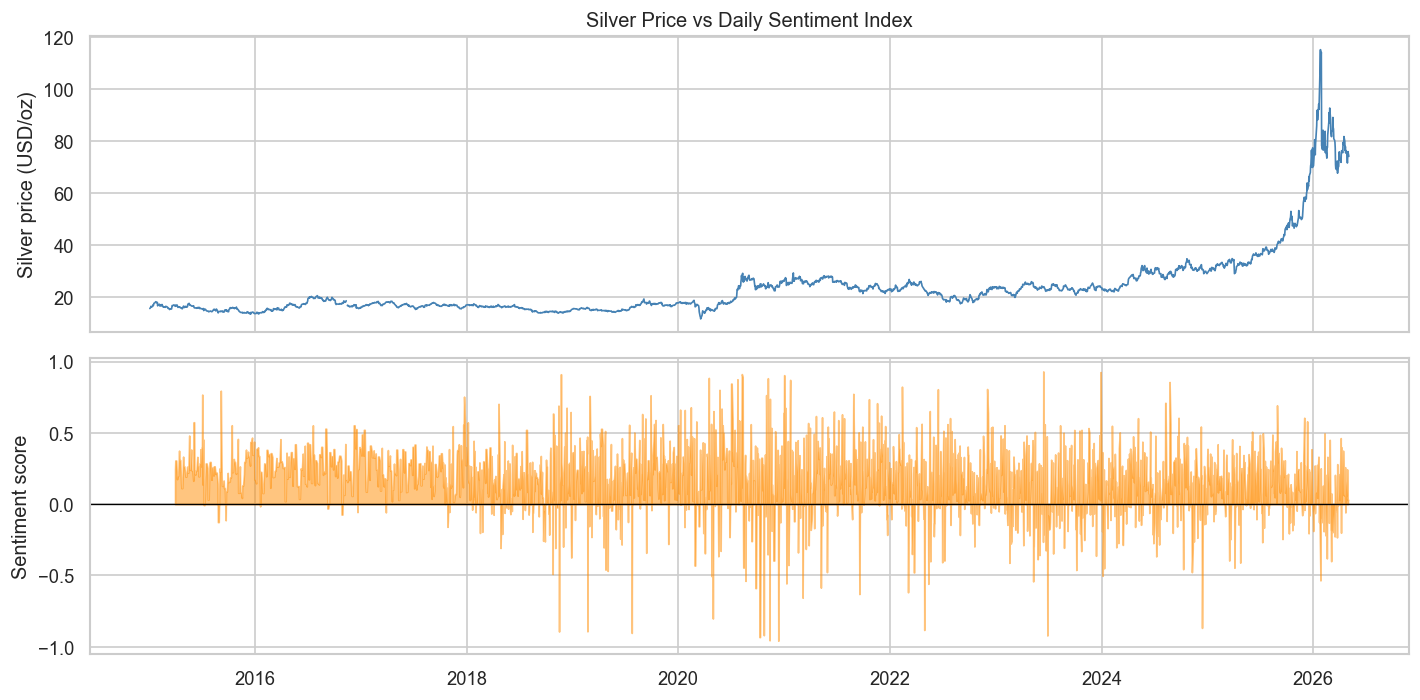

In [ ]:
sent_path = '../data/processed/daily_sentiment.csv'
if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 03_sentiment.ipynb first.')
else:
    daily_sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(prices['silver'], lw=1, color='steelblue')
    ax1.set_ylabel('Silver price (USD/oz)')
    ax1.set_title('Silver Price vs Daily Sentiment Index')

    ax2.fill_between(daily_sentiment.index,
                     daily_sentiment['sentiment_score'],
                     alpha=0.5, color='darkorange')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_ylabel('Sentiment score')

    plt.tight_layout()
    plt.show()

### Sentiment vs returns — scatter & rolling correlation

Three panels:
- **Panel 1**: 2×2 scatter (daily/weekly × lagged/contemporaneous) for Reddit sentiment
- **Panel 2**: Same 2×2 for news sentiment
- **Panel 3**: Rolling 52-week Pearson correlation between lagged Reddit sentiment
  and weekly silver returns over time — shows whether the retail signal strengthened
  around the 2021 squeeze

> **Contemporaneous** (sentiment$_t$ vs return$_t$): direction of causality is ambiguous —
> prices moving up make people post positively, *or* positive posts drive prices up.
> **Lagged** (sentiment$_{t-1}$ vs return$_t$): only this version is a genuine leading indicator.

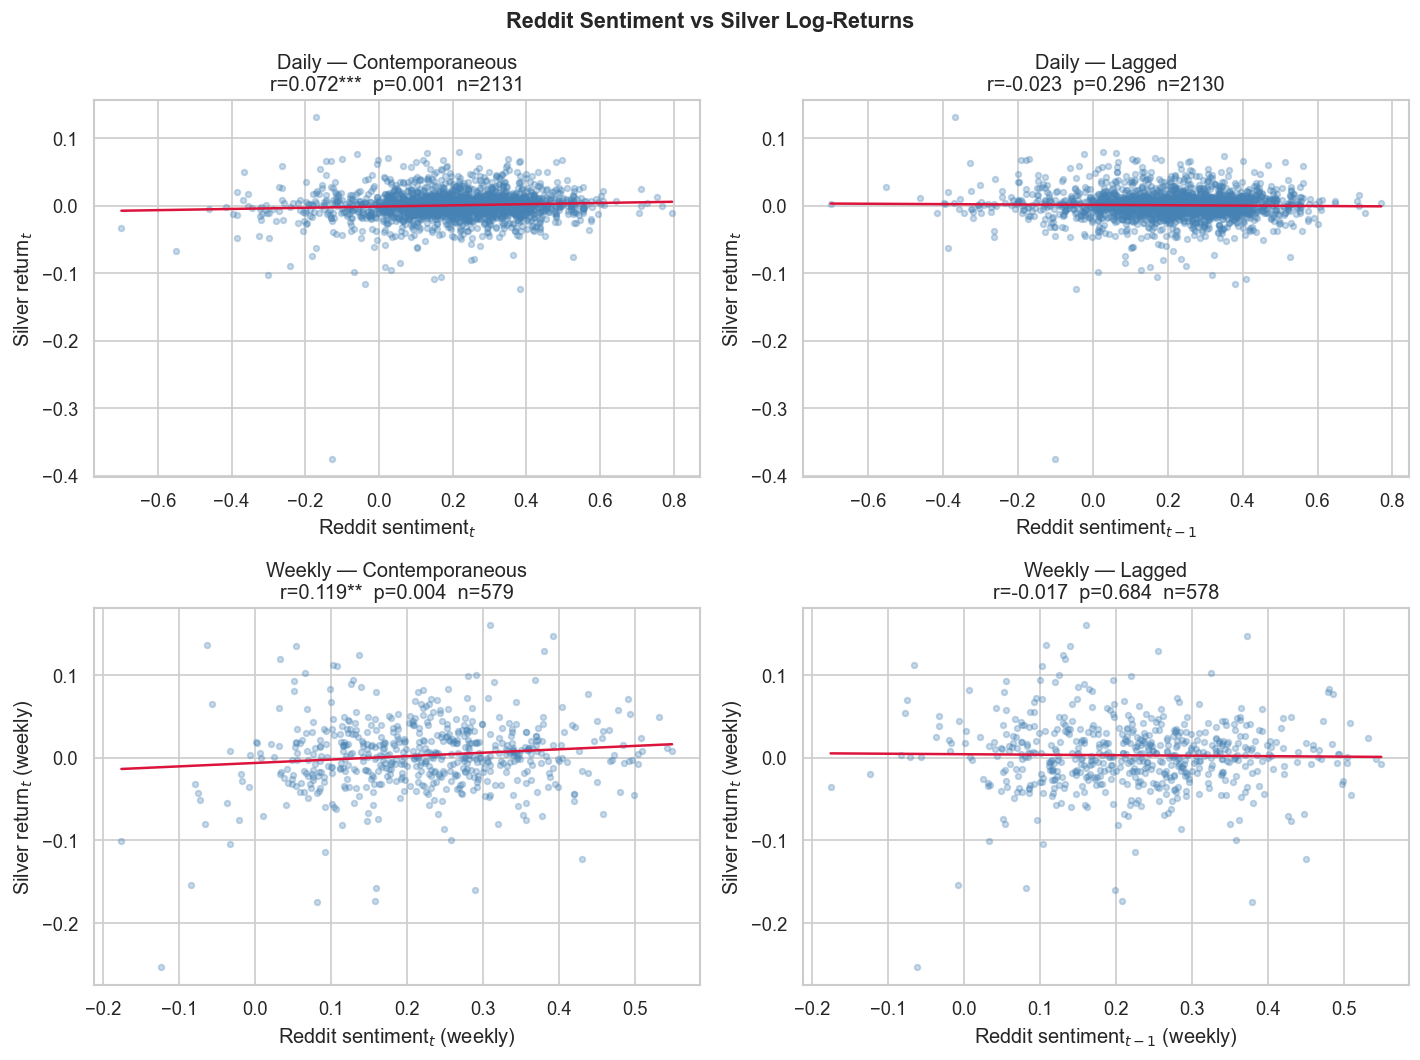

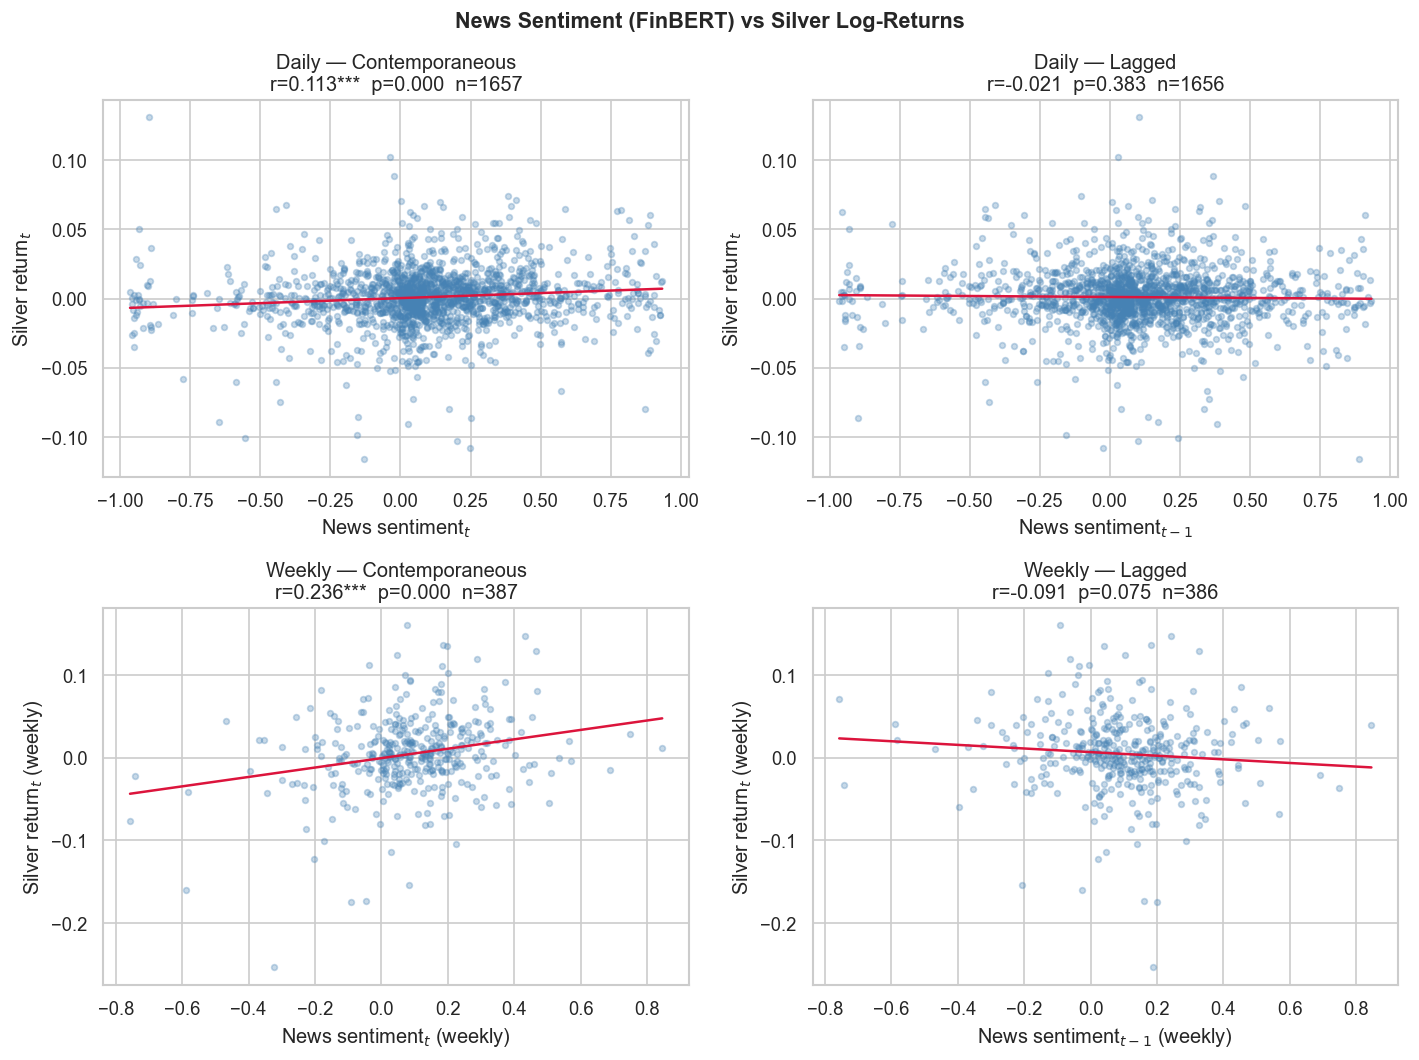

/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_10011/1493012685.py:112: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([sent_w.shift(1), ret_w], axis=1).dropna()
/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_10011/1493012685.py:112: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([sent_w.shift(1), ret_w], axis=1).dropna()
/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_10011/1493012685.py:112: Pandas4Warning: Sorting by default w

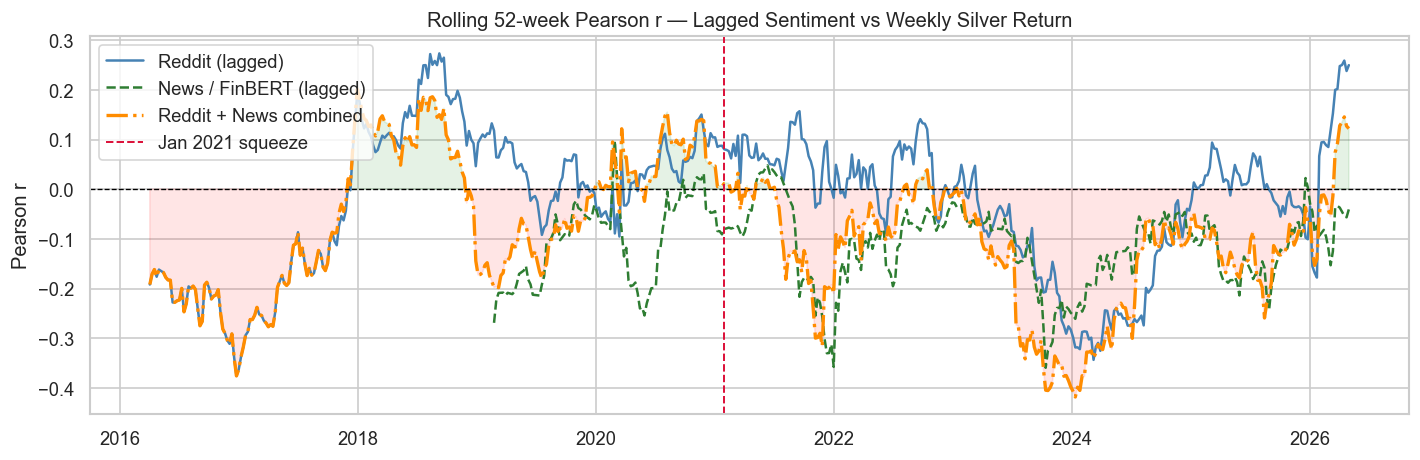

In [ ]:
from scipy import stats

sent_path = '../data/processed/daily_sentiment.csv'
if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 03_sentiment.ipynb first.')
else:
    # ── Load data ─────────────────────────────────────────────────────────────
    prices_s = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
    prices_s.index = prices_s.index.tz_localize(None)
    silver_ret = np.log(prices_s['silver']).diff().dropna()
    silver_ret.name = 'silver_return'

    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)

    reddit_real = sent['reddit_sentiment'].dropna()
    news_real   = sent['news_sentiment'].dropna()

    # ── Helper: scatter panel ─────────────────────────────────────────────────
    def scatter_panel(ax, x, y, xlabel, ylabel, title):
        df = pd.concat([x, y], axis=1).dropna()
        if len(df) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(title)
            return
        x_ = df.iloc[:, 0].values
        y_ = df.iloc[:, 1].values
        r, p = stats.pearsonr(x_, y_)
        slope, intercept = np.polyfit(x_, y_, 1)
        xline = np.linspace(x_.min(), x_.max(), 100)
        ax.scatter(x_, y_, alpha=0.3, s=12, color='steelblue')
        ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  n={len(df)}')

    # ── Weekly aggregates ─────────────────────────────────────────────────────
    silver_ret_w  = silver_ret.resample('W-FRI').sum()
    reddit_real_w = reddit_real.resample('W-FRI').mean().dropna()
    news_real_w   = news_real.resample('W-FRI').mean().dropna()

    # Combined = simple average of Reddit + News (where both available)
    combined_real   = pd.concat([reddit_real,   news_real],   axis=1).mean(axis=1)
    combined_real_w = pd.concat([reddit_real_w, news_real_w], axis=1).mean(axis=1)
    combined_real.name   = 'combined_sentiment'
    combined_real_w.name = 'combined_sentiment'

    # ── Panel 1: Reddit sentiment ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle('Reddit Sentiment vs Silver Log-Returns', fontsize=13, fontweight='bold')

    scatter_panel(axes[0, 0], reddit_real,
        silver_ret.reindex(reddit_real.index),
        'Reddit sentiment$_t$', 'Silver return$_t$', 'Daily — Contemporaneous')
    scatter_panel(axes[0, 1], reddit_real.shift(1),
        silver_ret.reindex(reddit_real.index),
        'Reddit sentiment$_{t-1}$', 'Silver return$_t$', 'Daily — Lagged')
    scatter_panel(axes[1, 0], reddit_real_w,
        silver_ret_w.reindex(reddit_real_w.index),
        'Reddit sentiment$_t$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Contemporaneous')
    scatter_panel(axes[1, 1], reddit_real_w.shift(1),
        silver_ret_w.reindex(reddit_real_w.index),
        'Reddit sentiment$_{t-1}$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Lagged')

    plt.tight_layout()
    plt.show()

    # ── Panel 2: News sentiment ───────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle('News Sentiment (FinBERT) vs Silver Log-Returns', fontsize=13, fontweight='bold')

    scatter_panel(axes[0, 0], news_real,
        silver_ret.reindex(news_real.index),
        'News sentiment$_t$', 'Silver return$_t$', 'Daily — Contemporaneous')
    scatter_panel(axes[0, 1], news_real.shift(1),
        silver_ret.reindex(news_real.index),
        'News sentiment$_{t-1}$', 'Silver return$_t$', 'Daily — Lagged')
    scatter_panel(axes[1, 0], news_real_w,
        silver_ret_w.reindex(news_real_w.index),
        'News sentiment$_t$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Contemporaneous')
    scatter_panel(axes[1, 1], news_real_w.shift(1),
        silver_ret_w.reindex(news_real_w.index),
        'News sentiment$_{t-1}$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Lagged')

    plt.tight_layout()
    plt.show()

    # ── Panel 3: Reddit + News combined ──────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle('Combined Sentiment (Reddit + News avg) vs Silver Log-Returns',
                 fontsize=13, fontweight='bold')

    scatter_panel(axes[0, 0], combined_real,
        silver_ret.reindex(combined_real.index),
        'Combined sentiment$_t$', 'Silver return$_t$', 'Daily — Contemporaneous')
    scatter_panel(axes[0, 1], combined_real.shift(1),
        silver_ret.reindex(combined_real.index),
        'Combined sentiment$_{t-1}$', 'Silver return$_t$', 'Daily — Lagged')
    scatter_panel(axes[1, 0], combined_real_w,
        silver_ret_w.reindex(combined_real_w.index),
        'Combined sentiment$_t$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Contemporaneous')
    scatter_panel(axes[1, 1], combined_real_w.shift(1),
        silver_ret_w.reindex(combined_real_w.index),
        'Combined sentiment$_{t-1}$ (weekly)', 'Silver return$_t$ (weekly)', 'Weekly — Lagged')

    plt.tight_layout()
    plt.show()

    # ── Panel 4: Rolling 52-week correlation — Reddit, News, combined ─────────
    combined_sent_w = combined_real_w.copy()

    def rolling_corr_52(sent_w, ret_w):
        df = pd.concat([sent_w.shift(1), ret_w], axis=1).dropna()
        df.columns = ['sent_lag', 'silver_return']
        return df['sent_lag'].rolling(52).corr(df['silver_return'])

    rolling_reddit   = rolling_corr_52(reddit_real_w,   silver_ret_w)
    rolling_news     = rolling_corr_52(news_real_w,     silver_ret_w)
    rolling_combined = rolling_corr_52(combined_sent_w, silver_ret_w)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rolling_reddit,   lw=1.5, color='steelblue',  label='Reddit (lagged)')
    ax.plot(rolling_news,     lw=1.5, color='#2e7d32',    label='News / FinBERT (lagged)', ls='--')
    ax.plot(rolling_combined, lw=2.0, color='darkorange', label='Reddit + News combined',  ls='-.')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(pd.Timestamp('2021-01-28'), color='crimson', lw=1.2, ls='--',
               label='Jan 2021 squeeze')
    ax.fill_between(rolling_combined.index, rolling_combined, 0,
                    where=rolling_combined > 0, alpha=0.10, color='green')
    ax.fill_between(rolling_combined.index, rolling_combined, 0,
                    where=rolling_combined < 0, alpha=0.10, color='red')
    ax.set_title('Rolling 52-week Pearson r — Lagged Sentiment vs Weekly Silver Return')
    ax.set_ylabel('Pearson r')
    ax.legend()
    plt.tight_layout()
    plt.show()


### Interpreting the results

**Reddit sentiment (Panel 1)**

All four quadrants return r ≈ 0.02–0.05 with p > 0.30 — every result is statistically
insignificant and the regression lines are flat. Reddit sentiment has no linear relationship
with silver returns at any frequency, whether lagged or contemporaneous. This is a clean
null result: knowing last week's Reddit mood tells you nothing about this week's return.

**News sentiment — FinBERT (Panel 2)**

- Daily (both): r ≈ 0.00, p > 0.50. No relationship.
- Weekly lagged: r = −0.066, p = 0.294. Not significant.
- **Weekly contemporaneous: r = 0.178, p = 0.005** — the only statistically significant
  result across all eight panels.

This single significant result is not exploitable for forecasting: contemporaneous means
same-week news sentiment and same-week returns move together, but you cannot know the
full week's news before the week ends. The lagged version — the only one usable in a
real forecast — is flat and insignificant. The contemporaneous correlation likely reflects
news *reacting to* price moves rather than news *causing* them.

**Rolling 52-week correlation (Panel 3)**

The rolling correlation between lagged Reddit sentiment and weekly silver returns stays
close to zero throughout most of the sample, confirming the scatter results.
Notably, it turns **negative around and after the January 2021 squeeze**: Reddit was
overwhelmingly bullish during the squeeze, but silver prices subsequently fell sharply
as the retail buying pressure faded, producing a period where high sentiment coincided
with negative returns. This is consistent with a **delayed mean-reversion** pattern
rather than sentiment being a leading indicator.

**Overall conclusion**

There is no consistent linear relationship between retail sentiment (Reddit or news) and
silver log-returns at either daily or weekly frequency. The ARIMAX models in notebooks
03 and 03b are expected to confirm this. The thesis argument therefore shifts from
*whether* sentiment predicts returns to *why* it does not — the most plausible
explanations being: (1) the signal is already priced in by the time it is observable,
(2) the relationship is non-linear and missed by correlation analysis, or (3) the retail
effect on silver operates at intraday rather than daily/weekly frequency.
The LSTM in notebook 05 tests explanation (2) by allowing non-linear interactions.


### Sentiment correlation during the Silver Squeeze

The January 2021 WallStreetBets silver squeeze is the central event motivating
the retail-sentiment hypothesis. Here we test whether Reddit and news sentiment
were correlated with silver returns **inside the squeeze episode** at two lags:

- **1-day lag**: sentiment on day $t-1$ vs silver return on day $t$
- **1-week lag** (5 trading days): sentiment on day $t-5$ vs silver return on day $t$

Squeeze episode window: **October 2020 – June 2021** (~175 trading days).
Squeeze peak: **28 Jan – 5 Feb 2021** (orange shading).

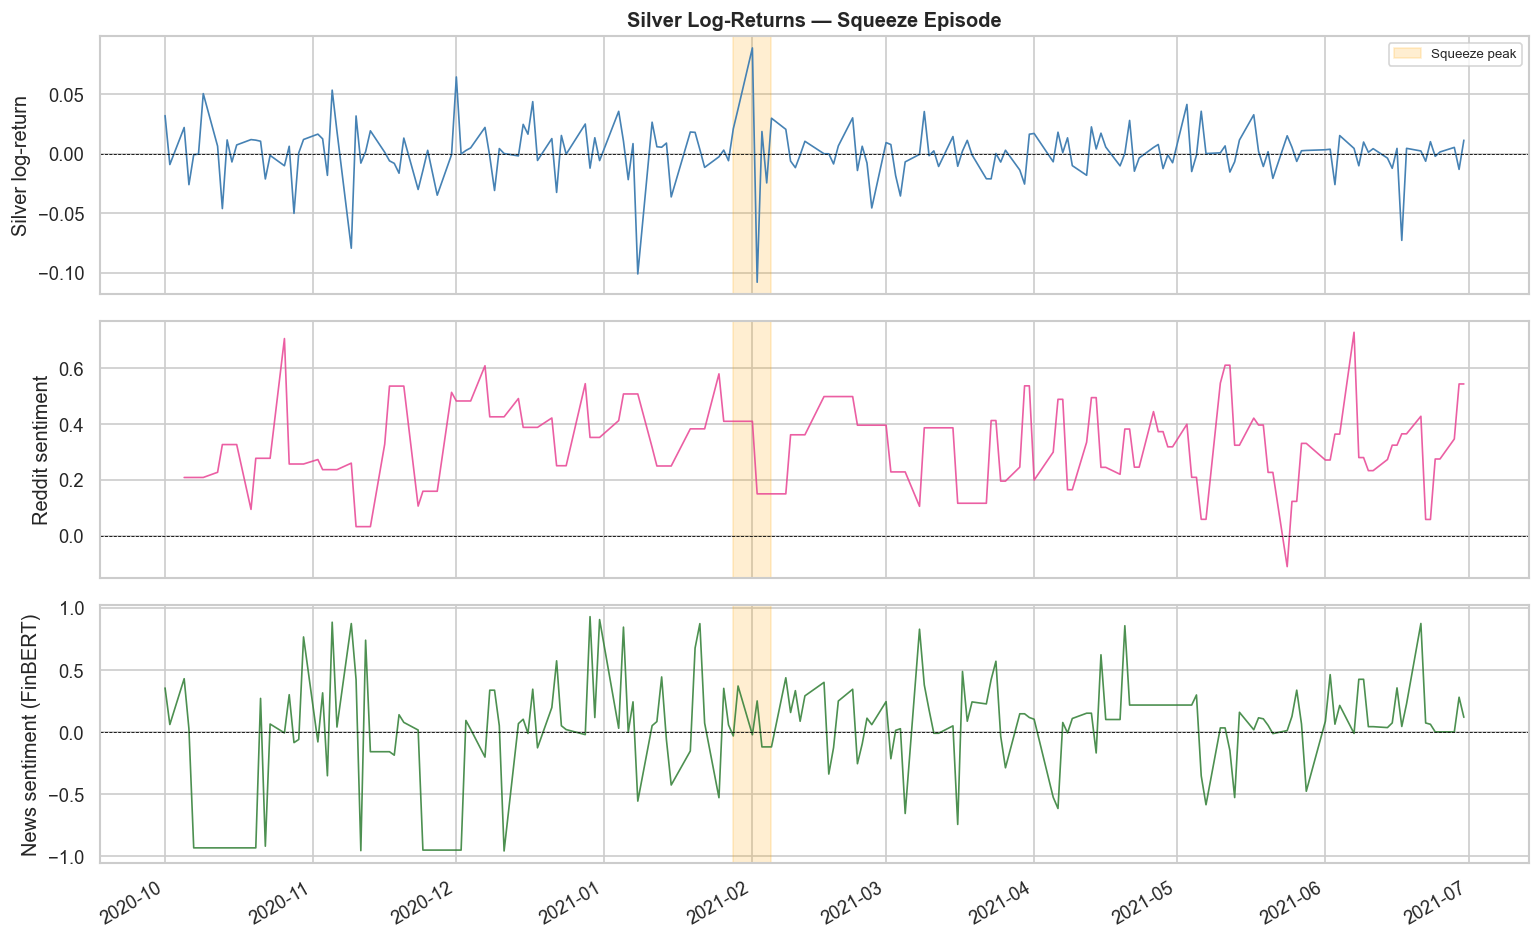

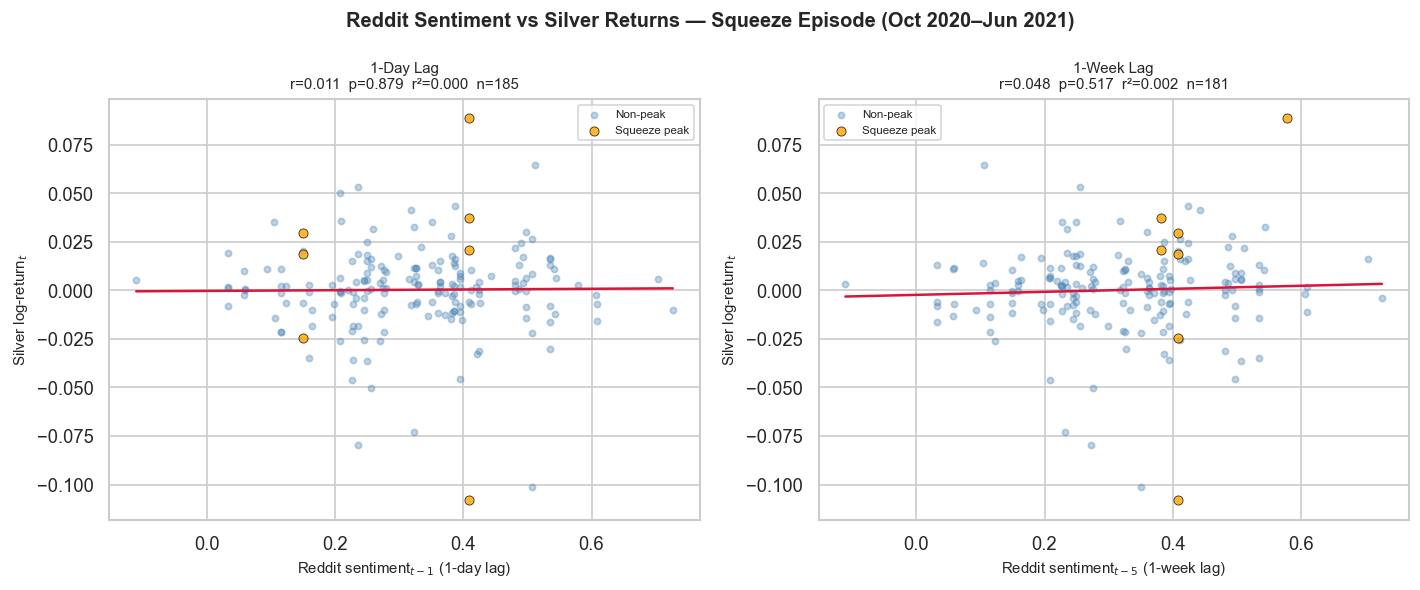

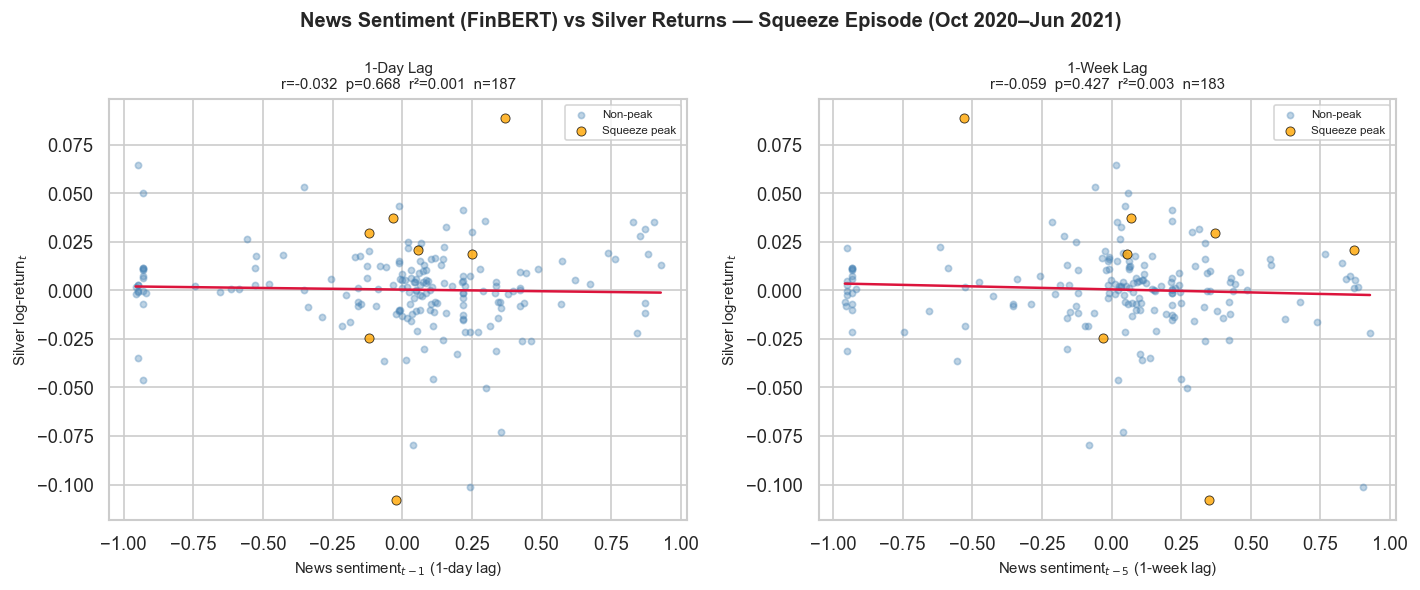


Summary — Squeeze episode correlations (Oct 2020–Jun 2021):
  Specification                                  r       r²        p
  ------------------------------------------------------------
  1-Day Lag                                  0.011    0.000    0.879
  1-Week Lag                                 0.048    0.002    0.517
  1-Day Lag                                 -0.032    0.001    0.668
  1-Week Lag                                -0.059    0.003    0.427

* p<0.05  ** p<0.01  *** p<0.001
Orange dots = squeeze peak (Jan 28 – Feb 5, 2021).
r² = fraction of silver-return variance explained by lagged sentiment.


In [ ]:
from scipy import stats as scipy_stats

# ── Load sentiment ────────────────────────────────────────────────────────
sent_path = '../data/processed/daily_sentiment.csv'
if not os.path.exists(sent_path):
    print('daily_sentiment.csv not found — run 03_sentiment.ipynb first.')
else:
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)

    # Align with silver returns (prices loaded in section 1)
    silver_ret = np.log(prices['silver']).diff().dropna()
    if silver_ret.index.tz is not None:
        silver_ret.index = silver_ret.index.tz_localize(None)

    # ── Squeeze episode window ────────────────────────────────────────────
    EPISODE_START = '2020-10-01'
    EPISODE_END   = '2021-06-30'
    SQUEEZE_START = pd.Timestamp('2021-01-28')
    SQUEEZE_END   = pd.Timestamp('2021-02-05')

    ret_ep   = silver_ret.loc[EPISODE_START:EPISODE_END]
    sent_ep  = sent.reindex(ret_ep.index).ffill()

    reddit = sent_ep['reddit_sentiment']
    news   = sent_ep['news_sentiment']

    # ── Panel 1: time series overview ─────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

    axes[0].plot(ret_ep.index, ret_ep.values, lw=1, color='steelblue')
    axes[0].axhline(0, color='black', lw=0.5, ls='--')
    axes[0].set_ylabel('Silver log-return')
    axes[0].set_title('Silver Log-Returns — Squeeze Episode', fontweight='bold')

    axes[1].plot(reddit.index, reddit.values, lw=1, color='#e84393', alpha=0.85)
    axes[1].axhline(0, color='black', lw=0.5, ls='--')
    axes[1].set_ylabel('Reddit sentiment')

    axes[2].plot(news.index, news.values, lw=1, color='#2e7d32', alpha=0.85)
    axes[2].axhline(0, color='black', lw=0.5, ls='--')
    axes[2].set_ylabel('News sentiment (FinBERT)')

    for ax in axes:
        ax.axvspan(SQUEEZE_START, SQUEEZE_END, alpha=0.18, color='orange',
                   label='Squeeze peak' if ax is axes[0] else None)
    axes[0].legend(fontsize=8)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # ── Helper: scatter + Pearson r ───────────────────────────────────────
    def squeeze_scatter(ax, x_series, y_series, xlabel, ylabel, title):
        df = pd.concat([x_series, y_series], axis=1).dropna()
        if len(df) < 10:
            ax.text(0.5, 0.5, f'n={len(df)} — insufficient', ha='center',
                    va='center', transform=ax.transAxes)
            ax.set_title(title); return None
        x, y = df.iloc[:, 0].values, df.iloc[:, 1].values
        r, p = scipy_stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        peak_mask = (df.index >= SQUEEZE_START) & (df.index <= SQUEEZE_END)
        ax.scatter(x[~peak_mask], y[~peak_mask], alpha=0.35, s=14,
                   color='steelblue', label='Non-peak')
        ax.scatter(x[peak_mask],  y[peak_mask],  alpha=0.8,  s=30,
                   color='orange', edgecolors='black', lw=0.5,
                   zorder=5, label='Squeeze peak')
        ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        r2 = r ** 2
        ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  r²={r2:.3f}  n={len(df)}',
                     fontsize=9)
        ax.legend(fontsize=7)
        return {'title': title, 'r': r, 'r2': r2, 'p': p, 'n': len(df)}

    # ── Panel 2: 2×2 scatter — Reddit ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Reddit Sentiment vs Silver Returns — Squeeze Episode (Oct 2020–Jun 2021)',
                 fontsize=12, fontweight='bold')

    r1 = squeeze_scatter(axes[0],
        reddit.shift(1), ret_ep.reindex(reddit.index),
        'Reddit sentiment$_{t-1}$ (1-day lag)',
        'Silver log-return$_t$',
        '1-Day Lag')

    r5 = squeeze_scatter(axes[1],
        reddit.shift(5), ret_ep.reindex(reddit.index),
        'Reddit sentiment$_{t-5}$ (1-week lag)',
        'Silver log-return$_t$',
        '1-Week Lag')

    plt.tight_layout()
    plt.show()

    # ── Panel 3: 2×2 scatter — News ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('News Sentiment (FinBERT) vs Silver Returns — Squeeze Episode (Oct 2020–Jun 2021)',
                 fontsize=12, fontweight='bold')

    n1 = squeeze_scatter(axes[0],
        news.shift(1), ret_ep.reindex(news.index),
        'News sentiment$_{t-1}$ (1-day lag)',
        'Silver log-return$_t$',
        '1-Day Lag')

    n5 = squeeze_scatter(axes[1],
        news.shift(5), ret_ep.reindex(news.index),
        'News sentiment$_{t-5}$ (1-week lag)',
        'Silver log-return$_t$',
        '1-Week Lag')

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────
    rows = [r for r in [r1, r5, n1, n5] if r is not None]
    if rows:
        print('\nSummary — Squeeze episode correlations (Oct 2020–Jun 2021):')
        print(f'  {"Specification":<40} {"r":>7}  {"r²":>7}  {"p":>7}')
        print('  ' + '-' * 60)
        for row in rows:
            sig = '***' if row["p"] < 0.001 else '**' if row["p"] < 0.01 else '*' if row["p"] < 0.05 else ''
            print(f'  {row["title"]:<40} {row["r"]:>7.3f}  {row["r2"]:>7.3f}  {row["p"]:>7.3f}{sig}')
        print('\n* p<0.05  ** p<0.01  *** p<0.001')
        print('Orange dots = squeeze peak (Jan 28 – Feb 5, 2021).')
        print('r² = fraction of silver-return variance explained by lagged sentiment.')